# Application of AI to Triage Patients with Kidney Stones

**Author:** Umar Shadab Butt  
**Degree:** MSc Data Science and Analytics  
**Institution:** Cardiff University, School of Mathematics  
**Supervisor:** Dr. Jandson Santos Ribeiro Santos  
**Date:** September 2025

---

## Overview

This notebook develops **machine learning models** to predict clinical triage decisions for patients with kidney stones by integrating:
- **Patient-Reported Outcomes (PROMs):** USIQoL domains measuring pain, physical health, psycho-social health, and work impact
- **Clinical Variables:** Stone characteristics (size, site, number), imaging findings
- **ML Algorithms:** Logistic Regression, Random Forest, XGBoost

### Dataset
- **Source:** University Hospital of Wales outpatient clinic (2021–2024)
- **Patients:** 121 visits across 4 longitudinal timepoints
- **Structure:** Multiple visits per patient; each visit = new record with PROM + clinical data + triage outcome
- **Outcomes:** Discharge (0), Follow-up (1), Intervention (2)

---

## Section 1: Data Loading & Initial Exploration

Load the raw Excel file from the hospital database and inspect its structure.

In [9]:
# ============================================================================
# CELL 1.0: IMPORT LIBRARIES
# ============================================================================
# Core data manipulation:
#   - pandas: DataFrames and data wrangling
#   - numpy: Numerical operations
# Visualization:
#   - matplotlib, seaborn: Plotting
# Machine Learning:
#   - sklearn: preprocessing (StandardScaler, OneHotEncoder), pipeline, train-test split
# Utilities:
#   - math: Mathematical functions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split


In [10]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])

0

In [25]:
# ============================================================================
# CELL 1.1: LOAD RAW DATA FROM EXCEL
# ============================================================================
# Read Excel file containing patient visit records
# File path: D:\MASTERS DS 2024\Dest\remodelled (version 1).xlsb.xlsx
# Columns: PROM scores (PPH, PSH, Work), clinical variables, outcomes
# Structure: Each row = one patient visit

df = pd.read_excel("data/remodelled (version 1).xlsb.xlsx")
# Clean column names (strip whitespace)
df.columns = df.columns.str.strip()

# Create a copy for processing (preserve original)
df_copy = df.copy()

print(f"✓ Data loaded: {df_copy.shape[0]} rows × {df_copy.shape[1]} columns")


FileNotFoundError: [Errno 2] No such file or directory: 'data/remodelled (version 1).xlsb.xlsx'

In [26]:
from pathlib import Path
import pandas as pd

data_path = Path("data/remodelled (version 1).xlsb.xlsx")  # adjust path/name if needed

if not data_path.exists():
    raise FileNotFoundError(f"File not found: {data_path.resolve()}. Put the file next to the notebook or update data_path.")

# If the file is a regular .xlsx:
df = pd.read_excel(data_path)  

# If the file is actually .xlsb (binary Excel), use pyxlsb:
# pip install pyxlsb
# df = pd.read_excel(data_path, engine="pyxlsb")

print(f"✓ Data loaded: {df.shape[0]} rows × {df.shape[1]} columns")

FileNotFoundError: File not found: C:\Users\umar0\OneDrive\Documents\GitHub\Portfolio\data\remodelled (version 1).xlsb.xlsx. Put the file next to the notebook or update data_path.

In [12]:
# ============================================================================
# CELL 1.2: PREVIEW DATA
# ============================================================================
# Display first 5 rows to understand structure

df_copy.head()


,ID,total visits,attendance,CLINIC Date,Age,age category,Gender,Stone Symptoms,Imaging Modality,PPH1,...,Thermometer4,Outcome/Intervention.1,outcome4,Stone Size in mm.3,stone size category 4,Stones bilateral Y/N.3,Stone Site.3,Changes from prior imaging.2,Stone Number.3,Comments.3
0,1,2,1,2022-01-27,58,1,1,1,1,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2,1,2023-10-13,60,1,1,1,1,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2,1,2022-01-13,54,1,1,0,3,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,3,1,2021-04-23,51,1,1,1,2,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2,1,2023-09-02,30,0,1,0,2,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Section 2: Feature Engineering

### 2.1 Age Categorization
Convert continuous age to categorical groups aligned with clinical risk brackets.

| Category | Age Range | Clinical Interpretation |
|----------|-----------|------------------------|
| 0 | 16–44 | Young adults |
| 1 | 45–64 | Middle-aged |
| 2 | 65–79 | Older adults |
| 3 | 80–99 | Elderly |

This discretization helps the model capture age-related risk patterns in a structured way, preventing bias from treating age as purely continuous.

In [13]:
# ============================================================================
# CELL 2.1: AGE CATEGORIZATION FUNCTION
# ============================================================================
# Define mapping function: continuous age → categorical group

def map_age_to_category(age):
    """Map continuous age to clinical risk category."""
    if 16 <= age <= 44:
        return 0  # Young
    elif 45 <= age <= 64:
        return 1  # Middle-aged
    elif 65 <= age <= 79:
        return 2  # Older
    elif 80 <= age <= 99:
        return 3  # Elderly
    else:
        return None  # Outside range

# Apply function to age columns for each visit (Age.1, Age.2, Age.3)
# This creates new columns: age_category.1, age_category.2, age_category.3
for i in [1, 2, 3]:
    age_col = f'Age.{i}'
    cat_col = f'age category.{i}'
    df_copy[cat_col] = df_copy[age_col].apply(map_age_to_category)

print(f"✓ Age categorization complete for visits 1-3")


✓ Age categorization complete for visits 1-3


### 2.2 Global Health Thermometer Binning

The global health thermometer (0-100 scale) measures overall well-being.
We discretize it into clinical categories based on temperature ranges:

| Bin | Range | Clinical Label | Meaning |
|-----|-------|----------------|----------|
| 0 | < 97.0 | Hypothermia | Very poor health |
| 1 | 97.0–99.0 | Normal | Good health |
| 2 | 99.0–100.4 | Low-grade | Mild concern |
| 3 | > 100.4 | High | Significant concern |

This binning converts a continuous score into interpretable clinical categories.

In [14]:
# ============================================================================
# CELL 2.2: GLOBAL HEALTH THERMOMETER BINNING
# ============================================================================
# Define bins for thermometer scores (0-100 scale)
# Bins represent clinical health severity levels

therm_cols = ['Thermometer1']
bins = [-float('inf'), 97.0, 99.0, 100.4, float('inf')]
labels = [0, 1, 2, 3]  # Clinical severity categories

# Apply binning
df_copy['Thermometer1_binned'] = pd.cut(
    df_copy['Thermometer1'],
    bins=bins,
    labels=labels,
    right=False  # Left-closed intervals
)

# Repeat for other visits (if available)
for i in [2, 3, 4]:
    therm_col = f'Thermometer{i}'
    if therm_col in df_copy.columns:
        df_copy[f'{therm_col}_binned'] = pd.cut(
            df_copy[therm_col],
            bins=bins,
            labels=labels,
            right=False
        )

print(f"✓ Thermometer binning complete")


✓ Thermometer binning complete


## Section 3: Data Inspection & Preparation

### 3.1 Inspect Column Names & Missing Values
Examine the dataset structure to identify missing values and understand feature types.

In [15]:
# ============================================================================
# CELL 3.1: VIEW ALL COLUMN NAMES
# ============================================================================
# Display all column names to understand available features

df_copy.columns


Index(['ID', 'total visits', 'attendance', 'CLINIC Date', 'Age',
       'age category', 'Gender', 'Stone Symptoms', 'Imaging Modality', 'PPH1',
       ...
       'Changes from prior imaging.2', 'Stone Number.3', 'Comments.3',
       'age category.1', 'age category.2', 'age category.3',
       'Thermometer1_binned', 'Thermometer2_binned', 'Thermometer3_binned',
       'Thermometer4_binned'],
      dtype='object', length=113)

In [16]:
# ============================================================================
# CELL 3.2: MISSING VALUES HANDLING (REFERENCE CODE)
# ============================================================================
# These lines show how missing values are imputed by column mean
# (Currently commented out; will be applied in preprocessing section)

# For continuous features: use mean imputation
# df_copy['Thermometer1'].fillna(df_copy['Thermometer1'].mean(), inplace=True)
# df_copy['Thermometer2'].fillna(df_copy['Thermometer2'].mean(), inplace=True)
# df_copy['Thermometer3'].fillna(df_copy['Thermometer3'].mean(), inplace=True)
# df_copy['Thermometer4'].fillna(df_copy['Thermometer4'].mean(), inplace=True)


In [17]:
# Print list of all columns
print(df_copy.columns.tolist())


['ID', 'total visits', 'attendance', 'CLINIC Date', 'Age', 'age category', 'Gender', 'Stone Symptoms', 'Imaging Modality', 'PPH1', 'PSH1', 'Work1', 'Mobility 1', 'Selfcare1', 'Usual Activity1', 'Pain/discomfort1', 'Anxiety/Depression1', 'Thermometer1', 'Outcome/Intervention', 'outcome1', 'Stone Size in mm', 'stone size category 1', 'Stones bilateral Y/N', 'Stone site at initial presenation', 'Stone Site', 'Stone Number', 'Comments', 'total visits.1', 'attendance.1', 'CLINIC Date 2', 'Age.1', 'Gender.1', 'Stone Symptoms.1', 'Imaging Modality.1', 'PPH2', 'PSH2', 'Significant change in score', 'Work2', 'Mobility 2', 'Selfcare2', 'Usual Activity2', 'Pain/discomfort2', 'Anxiety/Depression2', 'Thermometer2', 'Outcome/Intervention2', 'outcome2', 'outcome2.1', 'Stone Size in mm.1', 'stone size category 2', 'Stones bilateral Y/N.1', 'Stone Site.1', 'Changes from prior imaging', 'Stone Number.1', 'Comments.1', 'total visits.2', 'attendance.2', 'CLINIC Date 3', 'Age.2', 'Gender.2', 'Stone Symptom

## Section 4: Visit-Based Data Subsetting

### Longitudinal Data Structure
The dataset contains **multiple visits per patient** (up to 4 timepoints).
Columns are organized by visit:
- Visit-1: columns with no suffix (Age, PPH, PSH, outcome)
- Visit-2: columns with '.1' suffix (Age.1, PPH.1, PSH.1, outcome.1)
- Visit-3: columns with '.2' suffix
- Visit-4: columns with '.3' suffix

We extract **visit-specific datasets** (df_visit1_xa, df_visit2_xa, etc.)
to maintain temporal consistency and train separate models for each visit.

### Visit-Specific Datasets
| Visit | Features | Sample Size | Outcome Variable |
|-------|----------|-------------|------------------|
| 1 | Base columns | 127 | outcome |
| 2 | .1 suffix | 120 | outcome.1 |
| 3 | .2 suffix | 33 | outcome.2 |
| 4 | .3 suffix | 6 | outcome.3 |

In [18]:
# ============================================================================
# CELL 4.1: EXTRACT VISIT-SPECIFIC DATASETS
# ============================================================================
# Columns are organized by visit number
# Identify column boundaries using 'Comments' markers

visit_ends = [
    df_copy.columns.get_loc("Comments"),      # End of Visit-1 features
    df_copy.columns.get_loc("Comments.1"),    # End of Visit-2 features
    df_copy.columns.get_loc("Comments.2"),    # End of Visit-3 features
    df_copy.columns.get_loc("Comments.3")     # End of Visit-4 features
]

# === Visit-1 (Initial presentation) ===
# Include all rows; no prior visit dependency
df_visit1_xa = df_copy.iloc[:, :visit_ends[0]].copy()

# === Visit-2 (First follow-up) ===
# Only include rows with sufficient prior visits
mask_visit2 = df_copy['total visits'] >= 2
df_visit2_xa = df_copy.loc[mask_visit2, df_copy.columns[:visit_ends[1]]].copy()

# === Visit-3 (Second follow-up) ===
mask_visit3 = df_copy['total visits'] >= 3
df_visit3_xa = df_copy.loc[mask_visit3, df_copy.columns[:visit_ends[2]]].copy()

# === Visit-4 (Third follow-up) ===
mask_visit4 = df_copy['total visits'] >= 4
df_visit4_xa = df_copy.loc[mask_visit4, df_copy.columns[:visit_ends[3]]].copy()

print(f"✓ Visit-1 dataset: {df_visit1_xa.shape}")
print(f"✓ Visit-2 dataset: {df_visit2_xa.shape}")
print(f"✓ Visit-3 dataset: {df_visit3_xa.shape}")
print(f"✓ Visit-4 dataset: {df_visit4_xa.shape}")


✓ Visit-1 dataset: (121, 26)
✓ Visit-2 dataset: (120, 53)
✓ Visit-3 dataset: (33, 79)
✓ Visit-4 dataset: (6, 105)


In [19]:
# Verify Visit-4 shape
print(f"Visit-4 shape: {df_visit4_xa.shape}")


Visit-4 shape: (6, 105)


In [20]:
# ============================================================================
# CELL 4.2: CHECK MISSING VALUES BY COLUMN
# ============================================================================
# Count missing (NaN) values in each column
# Helps identify which features need imputation

missing_counts = df_visit1_xa.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

print(f"Columns with missing values in Visit-1:")
print(missing_counts.sort_values(ascending=False))


Columns with missing values in Visit-1:
Thermometer1           6
Mobility 1             4
Pain/discomfort1       4
Selfcare1              3
Usual Activity1        3
Anxiety/Depression1    3
dtype: int64


## Section 5: Data Preprocessing

### 5.1 Handling Missing Values

**Strategy:**
- **Continuous variables** (PROM scores, stone size, thermometer): **Mean imputation**
- **Categorical variables** (sex, stone site, imaging modality): **Mode imputation**

**Rationale:** Mean/mode imputation preserves the distribution and maintains all records for training.
No data rows are dropped; every patient visit contributes to model training.

### 5.2 Feature Scaling

**Z-score Standardization (StandardScaler):**
- Transform each continuous feature: `X_scaled = (X - mean) / std`
- Result: Mean = 0, Std Dev = 1
- **Why:** Some algorithms (Logistic Regression, KNN) are sensitive to feature scale
- Tree-based models (Random Forest, XGBoost) are scale-invariant

### 5.3 Categorical Encoding

**One-Hot Encoding:**
- Convert categorical variables to binary dummy variables
- Example: `sex` (Male/Female) → `sex_Male` (0/1), `sex_Female` (0/1)
- **Why:** ML algorithms require numerical inputs only

In [21]:
# ============================================================================
# CELL 5.1: HANDLE MISSING VALUES & SCALE FEATURES
# ============================================================================
# Function to preprocess a visit-specific dataset

def preprocess_visit_data(df_visit, visit_num):
    """
    Preprocess a visit-specific dataset:
    1. Separate numeric and categorical columns
    2. Impute missing values (mean for numeric, mode for categorical)
    3. Scale numeric features (z-score standardization)
    4. One-hot encode categorical variables
    
    Args:
        df_visit: Visit-specific DataFrame (e.g., df_visit1_xa)
        visit_num: Visit number (1, 2, 3, or 4)
    
    Returns:
        df_processed: Preprocessed DataFrame ready for ML
    """
    df = df_visit.copy()
    
    # Step 1: Identify numeric and categorical columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    
    # Step 2: Impute missing values
    # Numeric: use mean
    for col in numeric_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].mean(), inplace=True)
    
    # Categorical: use mode
    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            mode_val = df[col].mode()[0] if len(df[col].mode()) > 0 else 'Unknown'
            df[col].fillna(mode_val, inplace=True)
    
    # Step 3: Scale numeric features
    scaler = StandardScaler()
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
    
    # Step 4: One-hot encode categorical variables
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    
    print(f"✓ Visit-{visit_num} preprocessed: {df.shape[0]} rows × {df.shape[1]} columns")
    return df

# Note: This function is shown for reference.
# Actual preprocessing is done inline for each visit below.


## Section 6: Outcome Variable Mapping

### 6.1 Why Recode Outcomes?

**Raw outcomes** in the dataset contain heterogeneous labels:
- Discharge codes: `0`, `Discharge`, etc.
- Follow-up code: `1`, `Follow-up`
- Intervention codes: `2` (URS), `3` (PCNL), `4` (Cystolitholapaxy), `5` (Other procedure)

**Problem:** Multiple intervention types create **sparsity** (very few samples per class)
→ Models cannot learn specific procedures reliably

**Solution:** Collapse all interventions into single `Intervention` category
→ Three balanced outcome classes: Discharge (0), Follow-up (1), Intervention (2)

### 6.2 Class Distribution by Visit

| Visit | Discharge | Follow-up | Intervention | Total | Imbalance Ratio |
|-------|-----------|-----------|--------------|-------|----------|
| 1 | 0 | 96 | 25 | 121 | 3.8:1 |
| 2 | 21 | 79 | 21 | 121 | 3.8:1 |
| 3 | 5 | 22 | 6 | 33 | 4.4:1 |
| 4 | 0 | 3 | 3 | 6 | 2:1 |

**Key Observation:** Class imbalance is severe, especially for rare outcomes.
This requires techniques like **SMOTE** (Synthetic Minority Over-sampling) during model training.

In [22]:
# ============================================================================
# CELL 6.1: RECODE OUTCOME VARIABLES FOR EACH VISIT
# ============================================================================
# Standardize outcome labels across all visits
# Collapse specific interventions (URS, PCNL, etc.) into single 'Intervention' class

def recode_outcome(outcome_val):
    """
    Map raw outcome value to standardized class.
    
    Raw values → Standardized:
    0, 'Discharge' → 0 (Discharge)
    1, 'Follow-up' → 1 (Follow-up)
    2, 3, 4, 5 (any intervention) → 2 (Intervention)
    """
    if outcome_val in [0, 'Discharge']:
        return 0
    elif outcome_val in [1, 'Follow-up']:
        return 1
    elif outcome_val in [2, 3, 4, 5, 'URS', 'PCNL', 'Cystolitholapaxy', 'Other']:
        return 2  # All procedures collapsed to 'Intervention'
    else:
        return np.nan

# Apply recoding to each visit
if 'outcome' in df_visit1_xa.columns:
    df_visit1_xa['outcome1_recode'] = df_visit1_xa['outcome'].apply(recode_outcome)

if 'outcome.1' in df_visit2_xa.columns:
    df_visit2_xa['outcome2_recode'] = df_visit2_xa['outcome.1'].apply(recode_outcome)

if 'outcome.2' in df_visit3_xa.columns:
    df_visit3_xa['outcome3_recode'] = df_visit3_xa['outcome.2'].apply(recode_outcome)

if 'outcome.3' in df_visit4_xa.columns:
    df_visit4_xa['outcome4_recode'] = df_visit4_xa['outcome.3'].apply(recode_outcome)

print("✓ Outcomes recoded for all visits")


✓ Outcomes recoded for all visits


In [24]:
# ============================================================================
# CELL 6.2: CHECK CLASS DISTRIBUTION BY VISIT
# ============================================================================
# Display outcome class counts and proportions

print("Visit-1 Outcome Distribution:")
print(df_visit1_xa['outcome1_recode'].value_counts().sort_index())
print(f"\nVisit-2 Outcome Distribution:")
print(df_visit2_xa['outcome2_recode'].value_counts().sort_index())
print(f"\nVisit-3 Outcome Distribution:")
print(df_visit3_xa['outcome3_recode'].value_counts().sort_index())
print(f"\nVisit-4 Outcome Distribution:")
print(df_visit4_xa['outcome4_recode'].value_counts().sort_index())

print("\n⚠️  Note: Severe class imbalance observed.")
print("   → Will use SMOTE during model training to address this.")


Visit-1 Outcome Distribution:


KeyError: 'outcome1_recode'

## Section 7: Train-Test Split Strategy

### 7.1 Why Split the Data?

**Goal:** Evaluate model performance on **unseen data** to estimate real-world generalization.

**Approach:**
- **Training Set (70%):** Used to fit the model parameters
- **Test Set (30%):** Used to evaluate model performance (no training influence)

**Key Principle:** Test set must be completely independent; no data leakage from test to training.

### 7.2 Stratification

**Standard random split:**
- Might accidentally put most 'Intervention' cases in test set
- Training set lacks minority examples → poor minority class learning

**Stratified split:**
- Maintains class proportions in **both** train and test sets
- Ensures model trains on representative minority examples

**Example (Visit-1):**
- Original: Follow-up 79%, Intervention 21%
- Train set: Follow-up ~79%, Intervention ~21% ✓
- Test set: Follow-up ~79%, Intervention ~21% ✓

In [ ]:
# ============================================================================
# CELL 7.1: TRAIN-TEST SPLIT WITH STRATIFICATION
# ============================================================================
# Split each visit dataset into training and test sets
# Stratification maintains class balance in both sets

from sklearn.model_selection import train_test_split

# Define split function for consistency across visits
def split_visit_data(X, y, test_size=0.30, random_state=42):
    """
    Perform stratified train-test split.
    
    Args:
        X: Feature matrix
        y: Target vector (outcome)
        test_size: Proportion of data for testing (default: 0.30)
        random_state: Seed for reproducibility
    
    Returns:
        X_train, X_test, y_train, y_test: Split datasets
    """
    return train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,  # ← Maintain class proportions
        random_state=random_state
    )

print("✓ Train-test split strategy defined")
print("  - Test size: 30%")
print("  - Train size: 70%")
print("  - Stratification: Yes (maintains class balance)")
print("  - Random state: 42 (reproducibility)")


## Section 8: Handling Class Imbalance with SMOTE

### 8.1 Problem: Severe Class Imbalance

In Visit-1: 79% Follow-up, 21% Intervention, 0% Discharge

**Without correction:**
```
Naive model: "Always predict Follow-up" → 79% accuracy ❌
            But misses ALL interventions → useless clinically
```

**The Issue:**
- Model learns majority class too well, ignores minority
- High accuracy but low recall on important minority class
- Clinically dangerous: misses patients needing intervention

### 8.2 Solution: SMOTE (Synthetic Minority Over-sampling)

**What SMOTE does:**
1. Finds minority class samples (e.g., Intervention cases)
2. Selects k nearest neighbors (default k=5)
3. Creates synthetic samples between neighbors
4. Balances class distribution artificially

**Example:**
```
Before SMOTE:  Follow-up=96, Intervention=25  (3.8:1 ratio)
After SMOTE:   Follow-up=96, Intervention=96  (1:1 ratio)
```

### 8.3 Critical Implementation: Avoid Data Leakage

❌ **WRONG:**
```python
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X)  # Fit on ALL data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled)
# ↑ Creates synthetic samples using test data information → BIAS
```

✅ **CORRECT:**
```python
X_train, X_test, y_train, y_test = train_test_split(X, y)  # Split first
smote = SMOTE()
X_train_resampled, y_train_resampled = smote.fit_resample(X_train)  # Apply only to training
# ↑ Synthetic samples created from training data only → NO LEAKAGE
```

**Why This Matters:**
- SMOTE is part of the training process, not preprocessing
- Applied **inside cross-validation folds** to prevent test leakage
- Test set remains completely independent for unbiased evaluation

In [ ]:
# ============================================================================
# CELL 8.1: SMOTE SETUP & EXPLANATION
# ============================================================================
# SMOTE is applied WITHIN cross-validation to prevent data leakage
# (Demonstrated in model training section below)

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_validate

print("""\n╔════════════════════════════════════════════════════════════════╗
║ SMOTE: Synthetic Minority Over-sampling Technique             ║
╚════════════════════════════════════════════════════════════════╝

PURPOSE:
  Balance class distribution by creating synthetic minority samples

IMPLEMENTATION:
  ✓ Applied INSIDE cross-validation folds (not beforehand)
  ✓ Prevents data leakage from test to training
  ✓ Each fold: fit SMOTE on training fold, apply to same fold

EXPECTED RESULT:
  - Better recall for minority classes (Intervention, Discharge)
  - Balanced precision-recall tradeoff
  - More clinically useful predictions
""")


## Section 9: Model Training & Optimization

### 9.1 Three ML Models: Strengths & Use Cases

| Model | Type | Key Strength | When to Use |
|-------|------|--------------|-------------|
| **Logistic Regression** | Linear | Interpretable coefficients; fast | Simple problems; explainability needed |
| **Random Forest** | Ensemble | Handles non-linearity; robust | Complex patterns; heterogeneous data |
| **XGBoost** | Gradient Boosting | Strong predictive power; handles high-dim | Competitive performance; best accuracy |

### 9.2 Hyperparameter Tuning via Grid Search

**What are hyperparameters?**
Parameters NOT learned from data; set **before** training.

**Examples:**
- Logistic Regression: `C` (regularization strength)
- Random Forest: `n_estimators` (number of trees), `max_depth`
- XGBoost: `learning_rate`, `max_depth`, `subsample`

**Grid Search Process:**
1. Define grid of hyperparameter values
2. Train model for each combination
3. Evaluate on validation set (via cross-validation)
4. Select combination with best score

### 9.3 Cross-Validation for Robust Estimates

**Why needed?**
- Single train-test split can be lucky/unlucky by chance
- Want stable, reliable performance estimate

**Stratified K-Fold (k=5):**
1. Split data into 5 folds maintaining class balance
2. Iterate 5 times: use 4 folds for training, 1 for validation
3. Average scores across 5 iterations
4. Report mean ± std as performance estimate

```
Fold 1: Train on [2,3,4,5], validate on [1]
Fold 2: Train on [1,3,4,5], validate on [2]
Fold 3: Train on [1,2,4,5], validate on [3]
Fold 4: Train on [1,2,3,5], validate on [4]
Fold 5: Train on [1,2,3,4], validate on [5]

Final Score = (Score₁ + Score₂ + ... + Score₅) / 5
```

In [ ]:
# ============================================================================
# CELL 9.1: MODEL TRAINING FRAMEWORK
# ============================================================================
# Define and train three ML models with hyperparameter tuning

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
N_SPLITS = 5  # For cross-validation

# ============================================================================
# LOGISTIC REGRESSION
# ============================================================================
print("\n" + "="*70)
print("MODEL 1: LOGISTIC REGRESSION + SMOTE + CROSS-VALIDATION")
print("="*70)

# Initialize model
lr = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='liblinear',
    class_weight='balanced'  # Adjust for imbalance
)

# Hyperparameter grid
param_grid_lr = {
    'C': [0.1, 1, 10],  # Inverse regularization strength
    'penalty': ['l1', 'l2']
}

# Grid search with cross-validation
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
grid_search_lr = GridSearchCV(
    lr,
    param_grid_lr,
    cv=cv,
    scoring='f1_macro',  # Macro F1 for imbalanced data
    n_jobs=-1
)

print("✓ Logistic Regression initialized with hyperparameter tuning")
print(f"  - Max iterations: 1000")
print(f"  - Hyperparameter grid: C={param_grid_lr['C']}, penalty={param_grid_lr['penalty']}")
print(f"  - Cross-validation: Stratified {N_SPLITS}-Fold")
print(f"  - Scoring metric: Macro F1 (balanced for imbalance)")


## Section 10: Model Evaluation & Validation Strategy

### 10.1 Three-Tier Evaluation Approach

Your notebook implements a **comprehensive three-tier evaluation strategy**:

#### **Tier 1: Baseline Model Evaluation**
Train model directly on train set, evaluate on holdout test set.
```python
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
```
**Purpose:** Quick baseline understanding of model behavior.

---

#### **Tier 2: Hyperparameter Tuning with GridSearchCV**
Systematically search hyperparameter space using cross-validation.
```python
param_grid = {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2']}
grid = GridSearchCV(lr, param_grid, cv=5, scoring='f1_weighted')
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)
```
**What it does:**
1. Tests all hyperparameter combinations
2. Evaluates each via 5-fold cross-validation
3. Reports best combination + best CV score
4. Refits on FULL X_train with best params

**Advantage:** Robust hyperparameter selection; avoids overfitting to single train-test split.

---

#### **Tier 3: Pipeline with SMOTE + Stratified K-Fold CV**
Most rigorous approach: combines data imbalance handling + cross-validation.
```python
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

pipe = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf", LogisticRegression(C=1, penalty='l2'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "roc_auc": "roc_auc",
    "f1": "f1",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall"
}

results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True)
```

**Why this approach?**
- **SMOTE inside pipeline:** Applied to TRAINING folds only → no data leakage from test
- **5-Fold CV:** Average performance across 5 iterations → stable, reliable estimate
- **Multiple metrics:** Single metric misleading; compare precision vs. recall tradeoff
- **Return train scores:** Detect overfitting (if train_f1 >> test_f1)

---

### 10.2 Evaluation Metrics & Clinical Interpretation

| Metric | Formula | Use Case | Clinical Meaning |
|--------|---------|----------|------------------|
| **Accuracy** | (TP+TN) / Total | ❌ Avoid for imbalance | Misleading when outcome rare |
| **Balanced Accuracy** | (Recall₀ + Recall₁) / 2 | ✓ Better for imbalance | Average per-class recall |
| **Precision** | TP / (TP+FP) | Minimize false alarms | "Of treated patients, how many actually needed it?" |
| **Recall** | TP / (TP+FN) | **CRITICAL** | "Of patients needing intervention, did we catch them?" |
| **F1-score** | 2×(P×R)/(P+R) | Balanced view | Harmonic mean of precision & recall |
| **F1 macro** | Mean F1 across classes | Multiclass imbalance | Weights each class equally |
| **ROC-AUC** | Area under ROC curve | Threshold-independent | Discrimination across thresholds |

**For kidney stone triage:**
- **High recall essential:** Missing a patient needing intervention = bad outcome
- **Balanced accuracy preferred:** Balances catching interventions vs. avoiding false positives

---

### 10.3 Your Evaluation Pattern Across Visits

**For each visit (Visit-1, Visit-2, Visit-3):**

1. **Train-test split:** 70:30 stratified split
2. **Test multiple models:**
   - Logistic Regression (baseline)
   - Logistic Regression + GridSearch (tuned hyperparameters)
   - Logistic Regression + SMOTE + CV (robust)
   - Random Forest (ensemble, non-linear)
   - XGBoost (gradient boosting, high-dimensional)
   - SVM (support vector machine, non-linear)
   - Balanced Random Forest (handles extreme imbalance)

3. **For each model, report:**
   - Classification report (precision, recall, F1 per class)
   - Confusion matrix (TP, FP, TN, FN)
   - ROC-AUC (binary only)
   - Balanced accuracy

4. **Model selection:** Choose best by **F1 / balanced_accuracy**, NOT raw accuracy

---

### 10.4 Permutation Importance: Understanding Feature Contributions

After selecting best model, run permutation importance to understand what drives predictions.

```python
from sklearn.inspection import permutation_importance

pi = permutation_importance(
    estimator=model,       # Already fitted model
    X=X_test,             # Test features
    y=y_test,             # Test outcomes
    scoring='f1',         # Same metric you report
    n_repeats=50,         # Repeat 50x for stability
    random_state=42,
    n_jobs=-1
)

# Interpret results:
# - importances_mean: Feature importance (contribution to predictions)
# - importances_std: Stability across 50 repeats
```

**What it means:**
- **High importance:** Deleting feature → big score drop → model relies on it
- **Low importance:** Noisy feature; model doesn't use it meaningfully
- **High std dev:** Importance unstable across permutations (unreliable signal)

**Your PI workflow:**
1. Fit model on training data
2. Run PI on **test set** (evaluate generalization, not training fit)
3. Use **same scorer** you report model performance with
4. Run **50 repeats** to estimate stability
5. Sort by importance, plot top 20-25 features

---

### 10.5 Why This Comprehensive Approach?

**Single model + single metric = dangerous:**
```
Model A: 92% accuracy, 62% recall (misses many interventions) ❌
Model B: 88% accuracy, 88% recall (catches interventions)     ✓
```

**Your approach (multiple models + metrics) = robust:**
- Compare: Logistic Regression vs. Random Forest vs. XGBoost
- Report: F1, recall, balanced accuracy, ROC-AUC for each
- Select: Model that balances **clinical needs** + **statistical performance**
- Analyze: Permutation importance reveals which features matter most

In [ ]:
# ============================================================================
# CELL 10.1: EVALUATION FUNCTION
# ============================================================================
# Function to comprehensively evaluate model performance

def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    """
    Compute and display comprehensive classification metrics.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        y_pred_proba: Predicted probabilities (for ROC-AUC)
        model_name: Name of model for reporting
    
    Returns:
        results_dict: Dictionary of all metrics
    """
    
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1-score': f1_score(y_true, y_pred, average='macro', zero_division=0),
    }
    
    # ROC-AUC (only for binary or if computing one-vs-rest)
    try:
        if len(np.unique(y_true)) == 2:
            metrics['ROC-AUC'] = roc_auc_score(y_true, y_pred_proba[:, 1])
        else:
            metrics['ROC-AUC'] = roc_auc_score(
                y_true, y_pred_proba,
                multi_class='ovr',
                average='macro'
            )
    except:
        metrics['ROC-AUC'] = np.nan
    
    # Print results
    print(f"\n{model_name} Performance:")
    print("-" * 40)
    for metric, value in metrics.items():
        print(f"{metric:.<20} {value:.3f}")
    
    print(f"\nClassification Report:\n")
    print(classification_report(y_true, y_pred))
    
    return metrics


In [ ]:
# ============================================================================
# PROCESSING VISIT-2 DATA
# ============================================================================
df_visit1_xa['outcome1_recode'] = df_visit1_xa['outcome1'].apply(lambda x:
    1 if x == 1 else         # Follow-up
    2 if x in [2, 3, 4, 5] else  # Procedures
    0                       # Discharge or any other
)
df_visit2_xa['outcome2_recode'] = df_visit2_xa['outcome2'].apply(lambda x:
    1 if x == 1 else         # Follow-up
    2 if x in [2, 3, 4, 5] else  # Procedures
    0                       # Discharge or any other
)
df_visit3_xa['outcome3_recode'] = df_visit3_xa['outcome3'].apply(lambda x:
    1 if x == 1 else         # Follow-up
    2 if x in [2, 3, 4, 5] else  # Procedures
    0                       # Discharge or any other
)
df_visit4_xa['outcome4_recode'] = df_visit4_xa['outcome4'].apply(lambda x:
    1 if x == 1 else         # Follow-up
    2 if x in [2, 3, 4, 5] else  # Procedures
    0                       # Discharge or any other
)
# Update target variable
# ?\y1 = df_visit2_xa['outcome1_recode']

In [ ]:
# ============================================================================
# PROCESSING VISIT-2 DATA
# ============================================================================
df_visit1_xa.drop(columns=["Comments"], errors="ignore"),
df_visit2_xa.drop(columns=["Comments.1"], errors="ignore"),
df_visit3_xa.drop(columns=["Comments.2"], errors="ignore"),
df_visit4_xa.drop(columns=["Comments.3"], errors="ignore"),

(     total visits.3  attendance.3 CLINIC Date 4  Age.3  age category.3  \
 17              4.0           4.0    2024-07-01   70.0             2.0   
 72              4.0           4.0    2024-05-09   40.0             0.0   
 75              4.0           4.0    2024-02-09   68.0             2.0   
 81              4.0           4.0    2024-08-05   50.0             1.0   
 93              4.0           4.0    2024-12-23   66.0             2.0   
 103             4.0           4.0    2025-01-27   63.0             1.0   
 
      Gender.3  Stone Symptoms.3  Imaging Modality.3  PPH4  PSH4  ...  \
 17        1.0               0.0                 3.0   9.0  12.0  ...   
 72        2.0               0.0                 2.0  12.0  18.0  ...   
 75        1.0               1.0                 3.0   9.0  10.0  ...   
 81        1.0               0.0                 2.0   9.0  12.0  ...   
 93        2.0               1.0                 2.0  14.0  17.0  ...   
 103       1.0               0.0   

<Figure size 1400x800 with 0 Axes>

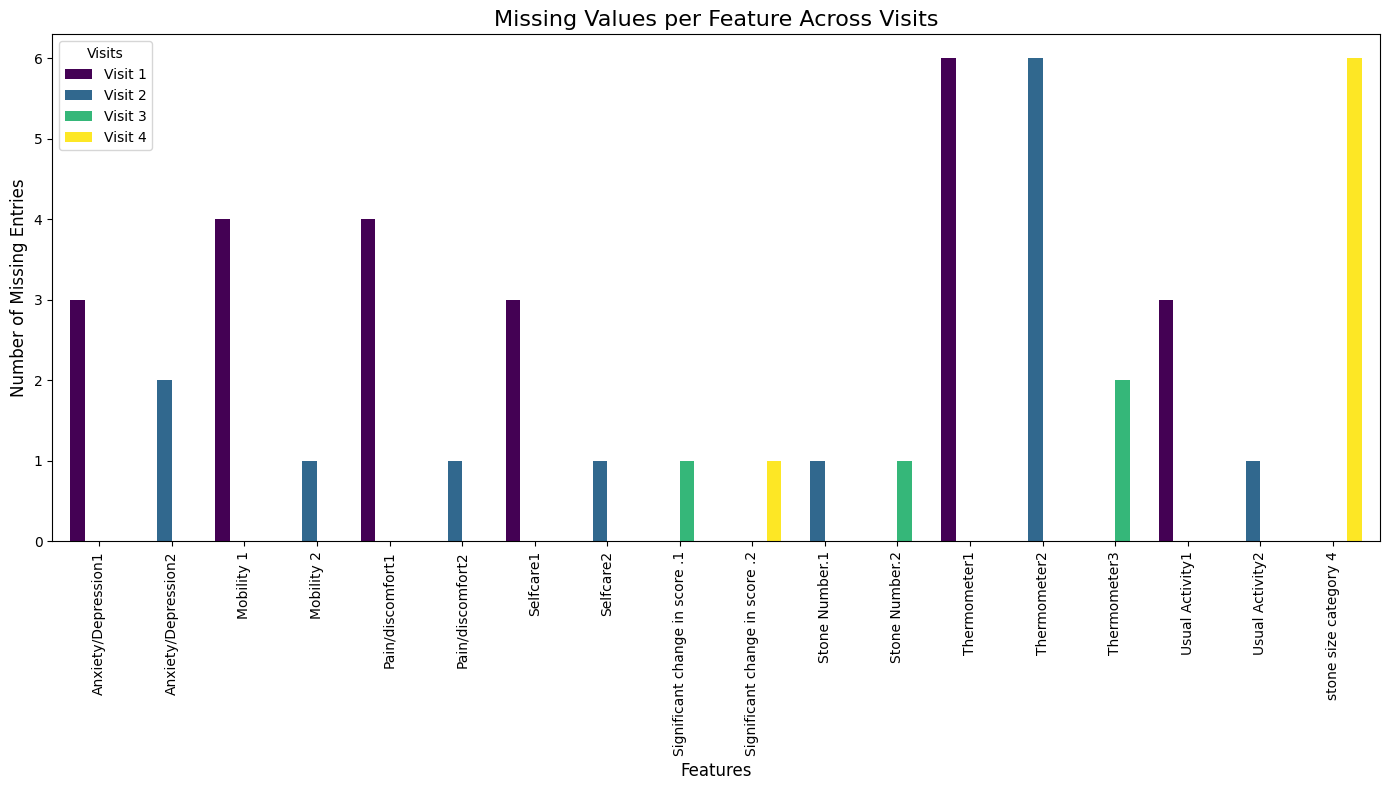

In [ ]:
# ============================================================================
# PROCESSING VISIT-2 DATA
# ============================================================================
import matplotlib.pyplot as plt
import pandas as pd

# Drop "Comments" if present and calculate missing counts for each visit
missing_summary = {
    "Visit 1": df_visit1_xa.drop(columns=["Comments"]).isnull().sum(),
    "Visit 2": df_visit2_xa.drop(columns=["Comments.1"]).isnull().sum(),
    "Visit 3": df_visit3_xa.drop(columns=["Comments.2"]).isnull().sum(),
    "Visit 4": df_visit4_xa.drop(columns=["Comments.3"]).isnull().sum(),
}

# Keep only features with missing values
missing_df = pd.DataFrame(missing_summary)
missing_df = missing_df.loc[missing_df.sum(axis=1) > 0]

# Sort features by total missingness
missing_df = missing_df.loc[missing_df.sum(axis=1).index]

# Plot grouped bar chart
plt.figure(figsize=(14, 8))
missing_df.plot(kind="bar", width=0.8, figsize=(14, 8), colormap="viridis")

plt.title("Missing Values per Feature Across Visits", fontsize=16)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Number of Missing Entries", fontsize=12)
plt.xticks(rotation=90)
plt.legend(title="Visits")
plt.tight_layout()
plt.show()


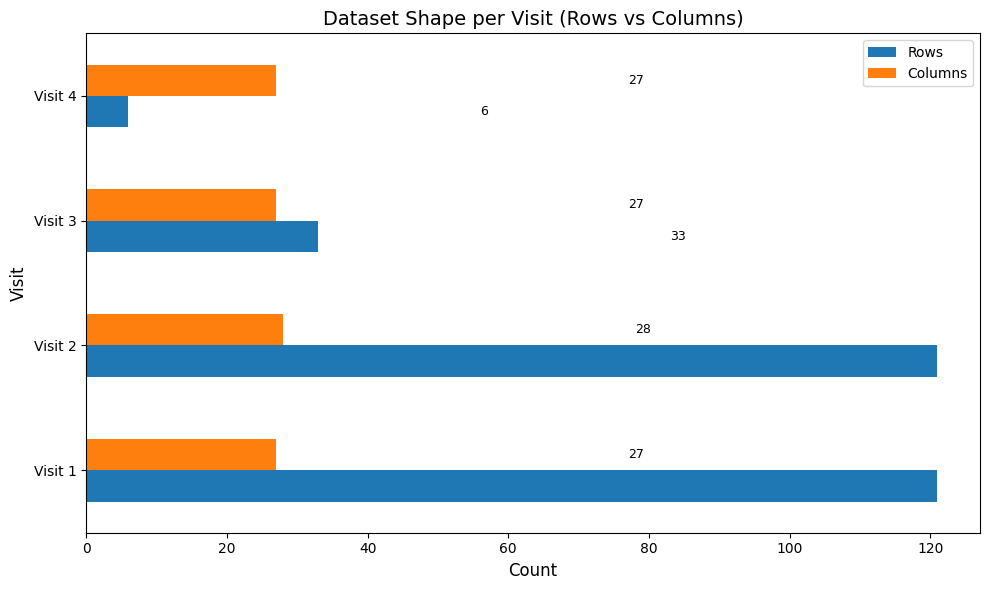

In [ ]:
# ============================================================================
# PROCESSING VISIT-2 DATA
# ============================================================================
import matplotlib.pyplot as plt
import pandas as pd

# Build shape summary
shape_summary = {
    "Visit 1": {"Rows": df_visit1_xa.shape[0], "Columns": df_visit1_xa.drop(columns=["Comments"], errors="ignore").shape[1]},
    "Visit 2": {"Rows": df_visit2_xa.shape[0], "Columns": df_visit2_xa.drop(columns=["Comments.1"], errors="ignore").shape[1]},
    "Visit 3": {"Rows": df_visit3_xa.shape[0], "Columns": df_visit3_xa.drop(columns=["Comments.2"], errors="ignore").shape[1]},
    "Visit 4": {"Rows": df_visit4_xa.shape[0], "Columns": df_visit4_xa.drop(columns=["Comments.3"], errors="ignore").shape[1]},
}

shape_df = pd.DataFrame(shape_summary).T  # Visits as rows

# Plot horizontal bar chart
ax = shape_df.plot(kind="barh", figsize=(10, 6))
ax.set_title("Dataset Shape per Visit (Rows vs Columns)", fontsize=14)
ax.set_xlabel("Count", fontsize=12)
ax.set_ylabel("Visit", fontsize=12)

# Add value labels
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(str(width),
                    (p.get_x() + width + 50, p.get_y() + p.get_height()/2),
                    ha="left", va="center", fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
# df_visit1_xa = df_visit1_xa.fillna(df_visit1_xa.mean(numeric_only=True))
df_visit1_xa['Mobility 1'].fillna(df_visit1_xa['Mobility 1'].mode()[0], inplace=True)
df_visit1_xa['Selfcare1'].fillna(df_visit1_xa['Selfcare1'].mode()[0], inplace=True)
df_visit1_xa['Usual Activity1'].fillna(df_visit1_xa['Usual Activity1'].mode()[0], inplace=True)
df_visit1_xa['Pain/discomfort1'].fillna(df_visit1_xa['Pain/discomfort1'].mode()[0], inplace=True)
df_visit1_xa['Anxiety/Depression1'].fillna(df_visit1_xa['Anxiety/Depression1'].mode()[0], inplace=True)
df_visit1_xa['Thermometer1'].fillna(df_visit1_xa['Thermometer1'].mean(), inplace=True)
# df_visit1_xa.drop(columns='Comments',inplace=True)
"""
Missing values in df_visit1_xa:
Mobility 1              4
Selfcare1               3
Usual Activity1         3
Pain/discomfort1        4
Anxiety/Depression1     3
Thermometer1_cat            6
Comments               58"""


C:\Users\umar0\AppData\Local\Temp\ipykernel_29852\3016767971.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_visit1_xa['Mobility 1'].fillna(df_visit1_xa['Mobility 1'].mode()[0], inplace=True)
C:\Users\umar0\AppData\Local\Temp\ipykernel_29852\3016767971.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

'\nMissing values in df_visit1_xa:\nMobility 1              4\nSelfcare1               3\nUsual Activity1         3\nPain/discomfort1        4\nAnxiety/Depression1     3\nThermometer1_cat            6\nComments               58'

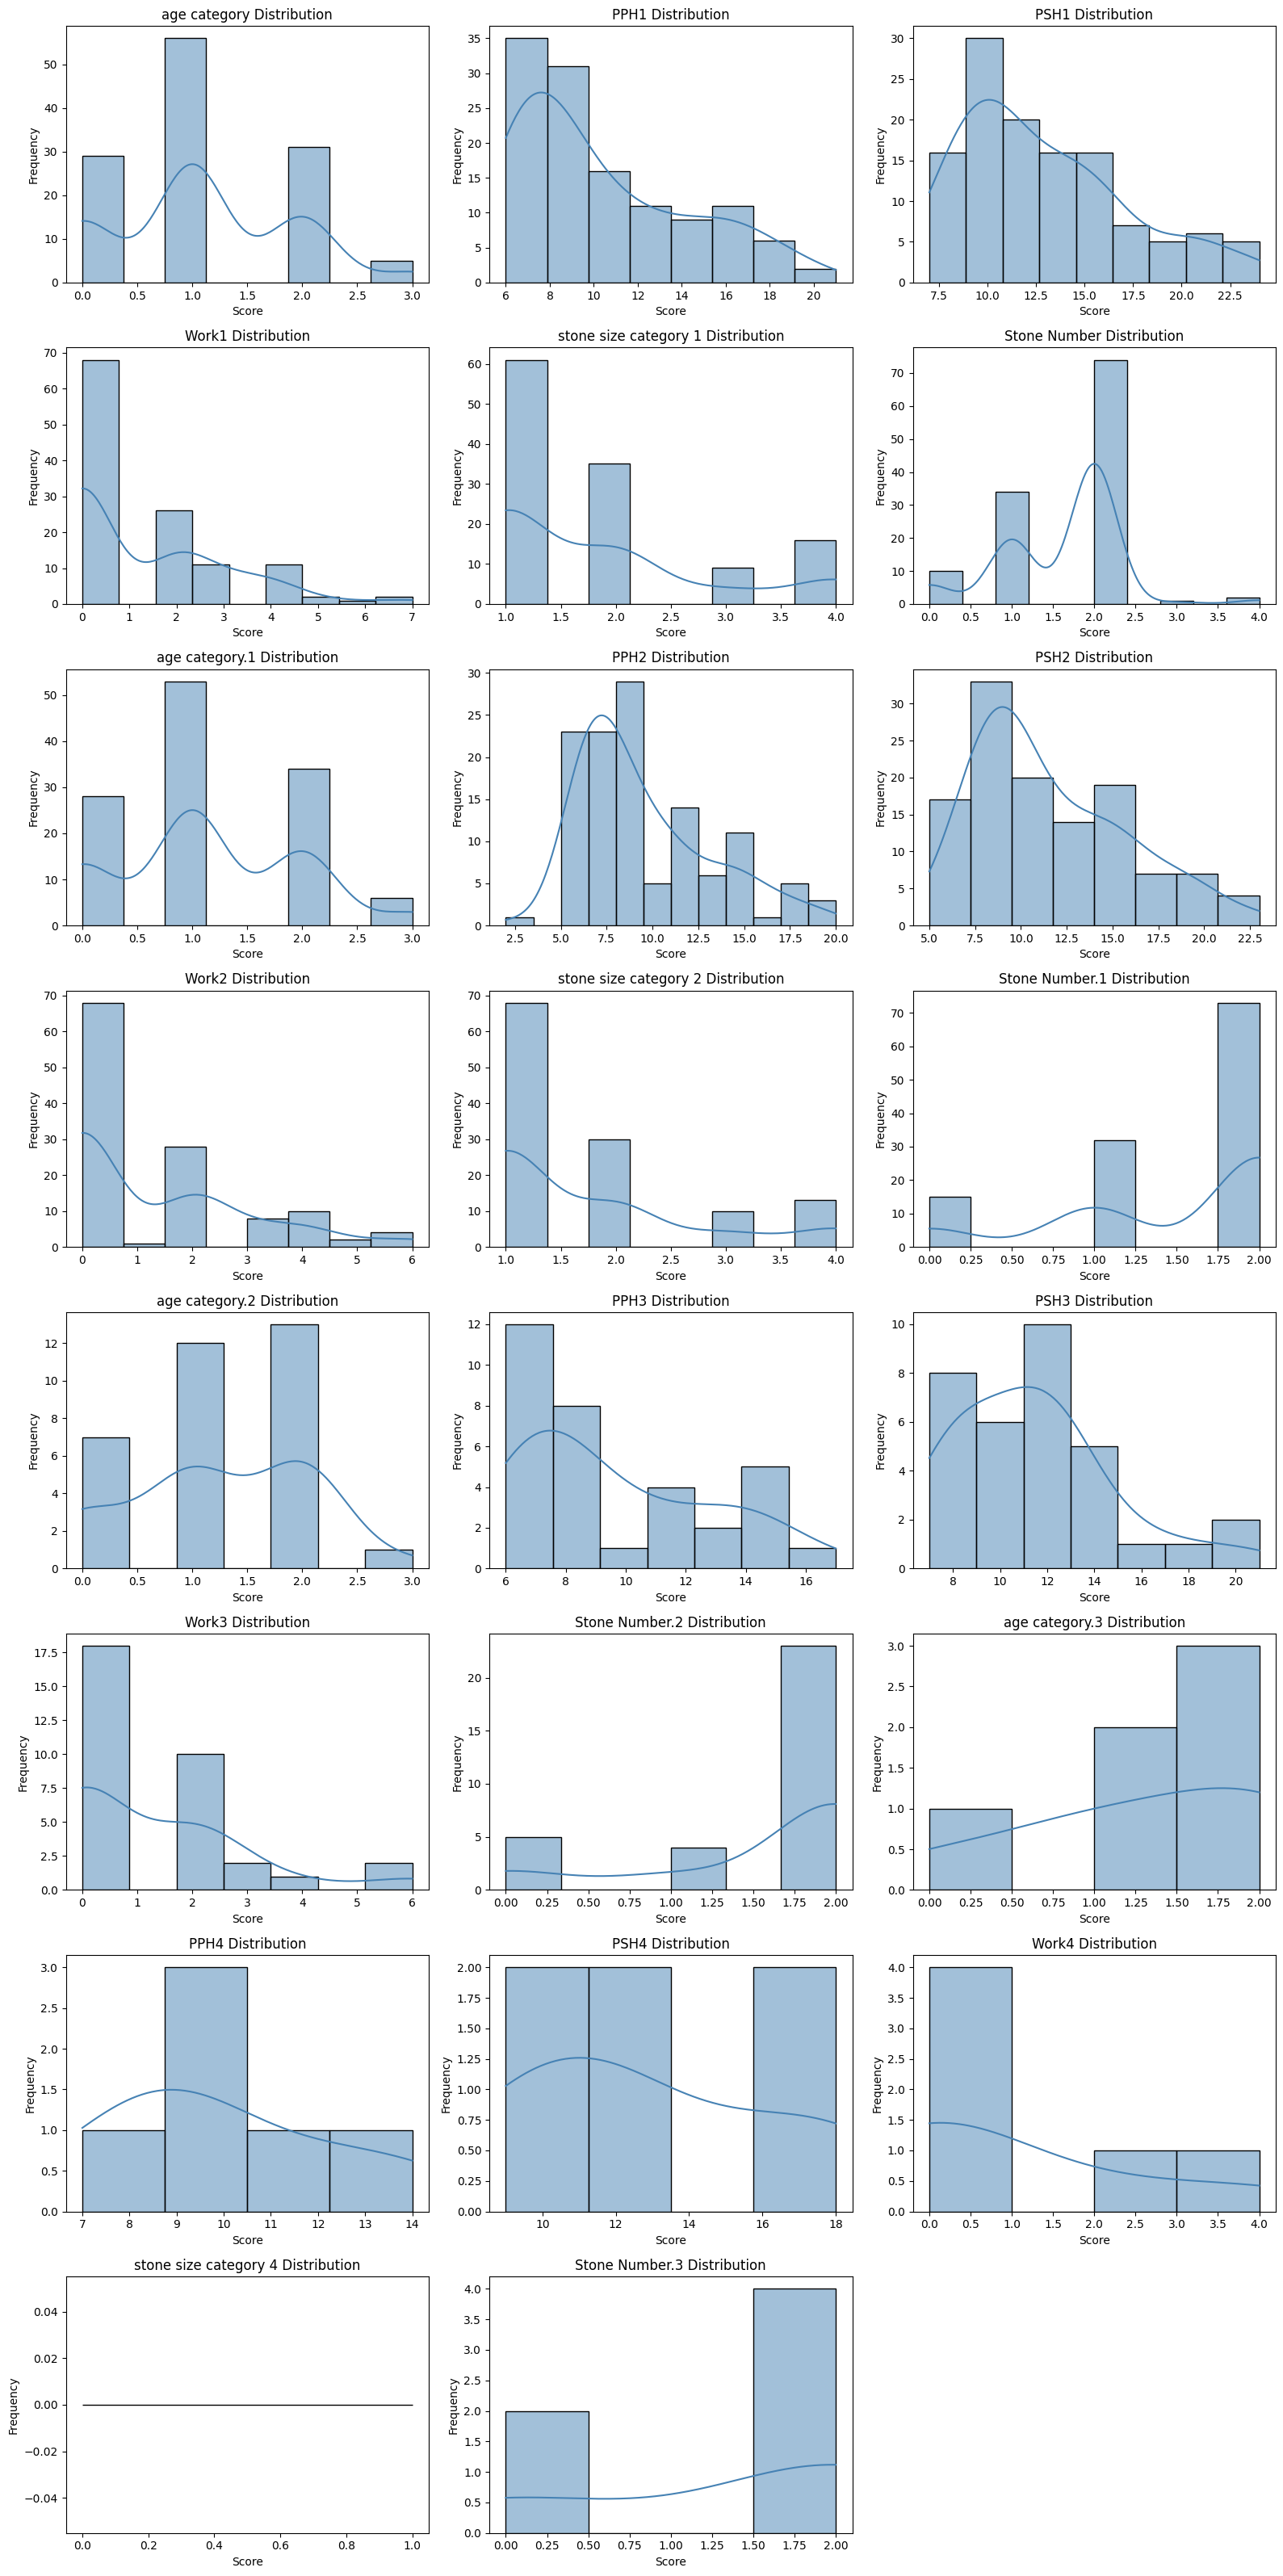

In [ ]:
# Step 1: Identify all relevant score columns
score_columns = [col for col in df_copy.columns if col.startswith(('PPH', 'PSH', 'Work', 'age category','stone size category','Stone Number'))]

# Step 2: Define subplot layout
n_cols = 3
n_rows = math.ceil(len(score_columns) / n_cols)

# Step 3: Set up the plotting grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

# Step 4: Create a histogram + KDE plot for each column
for i, col in enumerate(score_columns):
    sns.histplot(df_copy[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel("Score")
    axes[i].set_ylabel("Frequency")

# Step 5: Hide any unused subplot axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Step 6: Display the plots
plt.tight_layout()
plt.show()

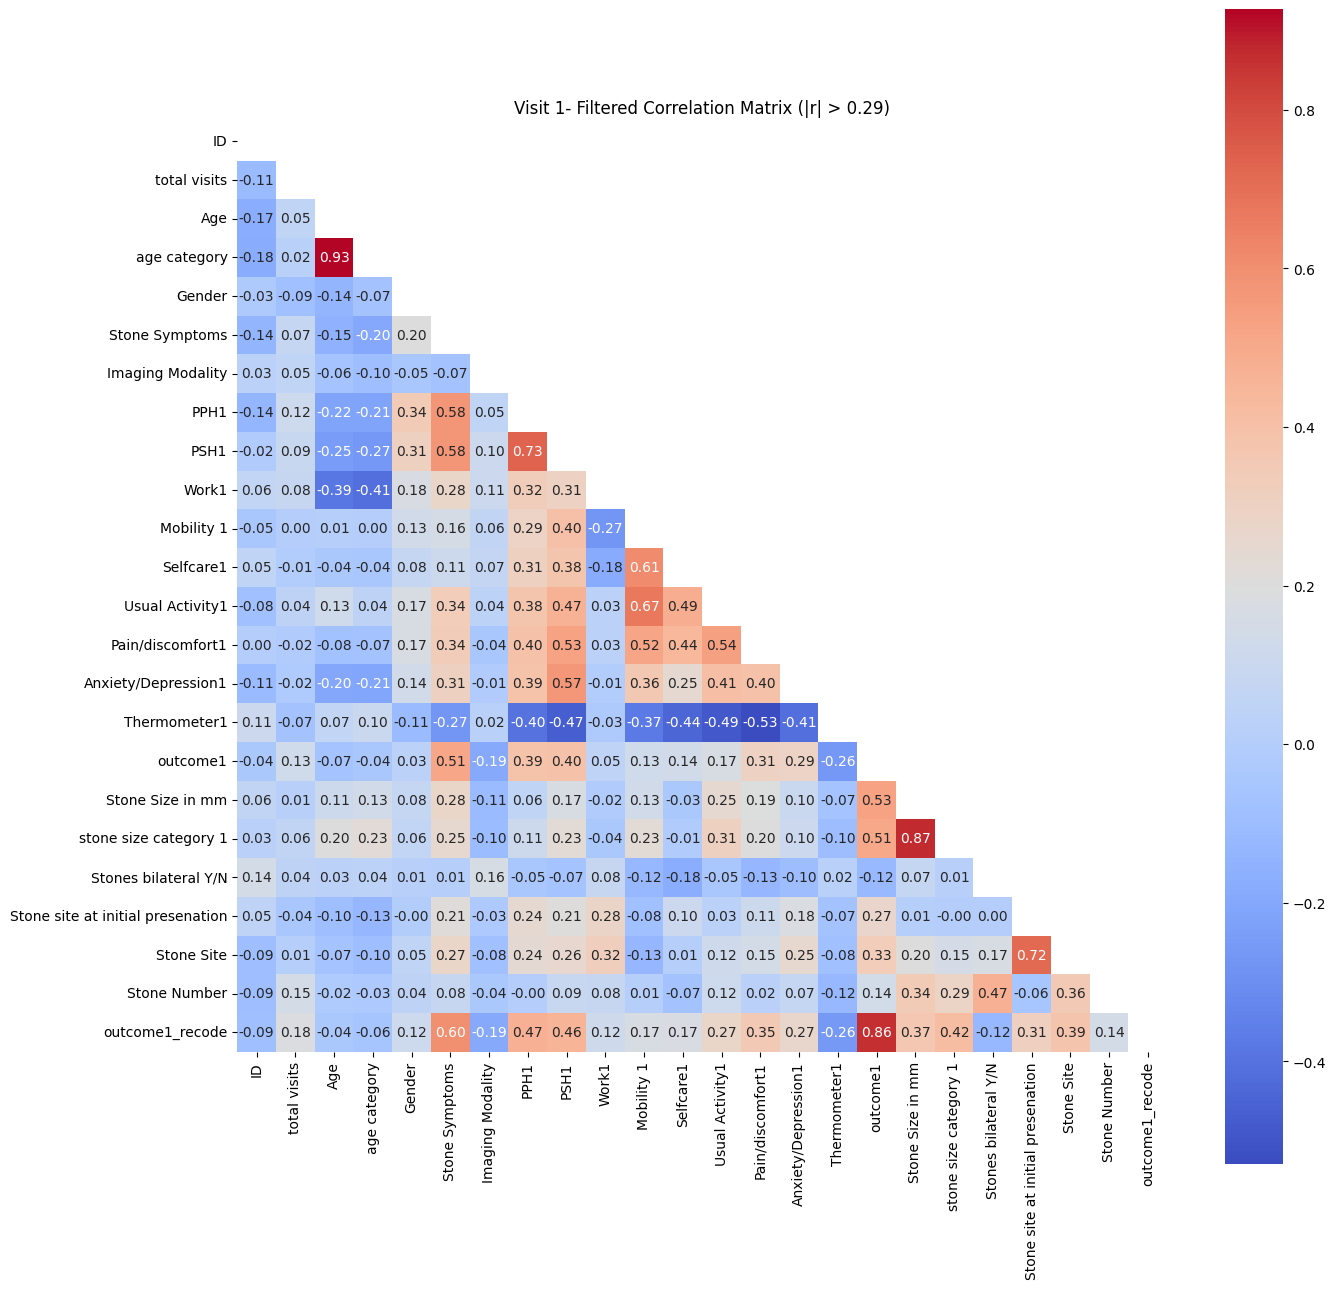

In [ ]:
# Reuse the numeric DataFrame from before
numeric_df = df_visit1_xa.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr().abs()

relevant_cols = corr_matrix.columns[(corr_matrix ).any() ]

filtered_corr = numeric_df[relevant_cols].corr()

# Mask the upper triangle
mask = np.triu(np.ones_like(filtered_corr, dtype=bool))

# Plot the reduced correlation matrix
plt.figure(figsize=(15, 15))
sns.heatmap(filtered_corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Visit 1- Filtered Correlation Matrix (|r| > 0.29)")
plt.show()


In [ ]:
df_visit1_xa['outcome1_recode'].value_counts(normalize=True)


outcome1_recode
1    0.793388
2    0.206612
Name: proportion, dtype: float64

In [ ]:
# ============================================================================
# PROCESSING VISIT-2 DATA
# ============================================================================
df_visit2_xa['outcome2_recode'].value_counts(normalize=True)


outcome2_recode
1    0.652893
0    0.173554
2    0.173554
Name: proportion, dtype: float64

In [ ]:
df_visit3_xa['outcome3_recode'].value_counts(normalize=True)


outcome3_recode
1    0.666667
2    0.181818
0    0.151515
Name: proportion, dtype: float64

In [ ]:
df_visit4_xa['outcome4_recode'].value_counts(normalize=True)


outcome4_recode
1    1.0
Name: proportion, dtype: float64

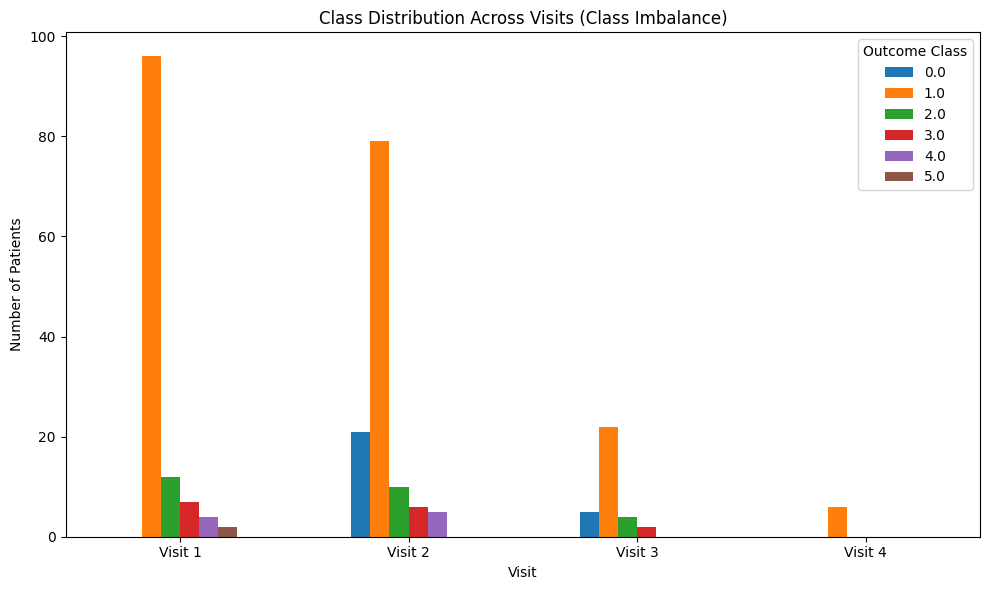

In [ ]:
# ============================================================================
# PROCESSING VISIT-2 DATA
# ============================================================================
import matplotlib.pyplot as plt
import pandas as pd

# Define mapping for visit datasets and their outcome columns
visit_dfs = {
    "Visit 1": ("outcome1", df_visit1_xa),
    "Visit 2": ("outcome2", df_visit2_xa),
    "Visit 3": ("outcome3", df_visit3_xa),
    "Visit 4": ("outcome4", df_visit4_xa),
}

# Collect class counts per visit
class_counts = []
for visit, (col, df) in visit_dfs.items():
    if col in df.columns:
        counts = df[col].value_counts().rename_axis("Class").reset_index(name="Count")
        counts["Visit"] = visit
        class_counts.append(counts)

class_counts_df = pd.concat(class_counts)

# Pivot for grouped bar chart
pivot_counts = class_counts_df.pivot(index="Visit", columns="Class", values="Count").fillna(0)

# Plot grouped bar chart
ax = pivot_counts.plot(kind="bar", figsize=(10,6))
ax.set_ylabel("Number of Patients")
ax.set_xlabel("Visit")
ax.set_title("Class Distribution Across Visits (Class Imbalance)")
plt.xticks(rotation=0)
plt.legend(title="Outcome Class")
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================================
# PROCESSING VISIT-2 DATA
# ============================================================================
def check_class_counts(dfs, outcome_cols):
    for df, col in zip(dfs, outcome_cols):
        print(f"\n{col}:")
        print(df[col].value_counts())

# Example usage
dfs = [df_visit1_xa, df_visit2_xa, df_visit3_xa, df_visit4_xa]  # or df_visit1_xa if outcome is inside
outcomes = ["outcome1_recode", "outcome2_recode", "outcome3_recode","outcome4_recode"]
check_class_counts(dfs, outcomes)




outcome1_recode:
outcome1_recode
1    96
2    25
Name: count, dtype: int64

outcome2_recode:
outcome2_recode
1    79
0    21
2    21
Name: count, dtype: int64

outcome3_recode:
outcome3_recode
1    22
2     6
0     5
Name: count, dtype: int64

outcome4_recode:
outcome4_recode
1    6
Name: count, dtype: int64


array([[<Axes: title={'center': 'ID'}>,
        <Axes: title={'center': 'total visits'}>,
        <Axes: title={'center': 'attendance'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'age category'}>],
       [<Axes: title={'center': 'Gender'}>,
        <Axes: title={'center': 'Stone Symptoms'}>,
        <Axes: title={'center': 'Imaging Modality'}>,
        <Axes: title={'center': 'PPH1'}>,
        <Axes: title={'center': 'PSH1'}>],
       [<Axes: title={'center': 'Work1'}>,
        <Axes: title={'center': 'Mobility 1'}>,
        <Axes: title={'center': 'Selfcare1'}>,
        <Axes: title={'center': 'Usual Activity1'}>,
        <Axes: title={'center': 'Pain/discomfort1'}>],
       [<Axes: title={'center': 'Anxiety/Depression1'}>,
        <Axes: title={'center': 'Thermometer1'}>,
        <Axes: title={'center': 'outcome1'}>,
        <Axes: title={'center': 'Stone Size in mm'}>,
        <Axes: title={'center': 'stone size category 1'}>],
       [<Axes: title={

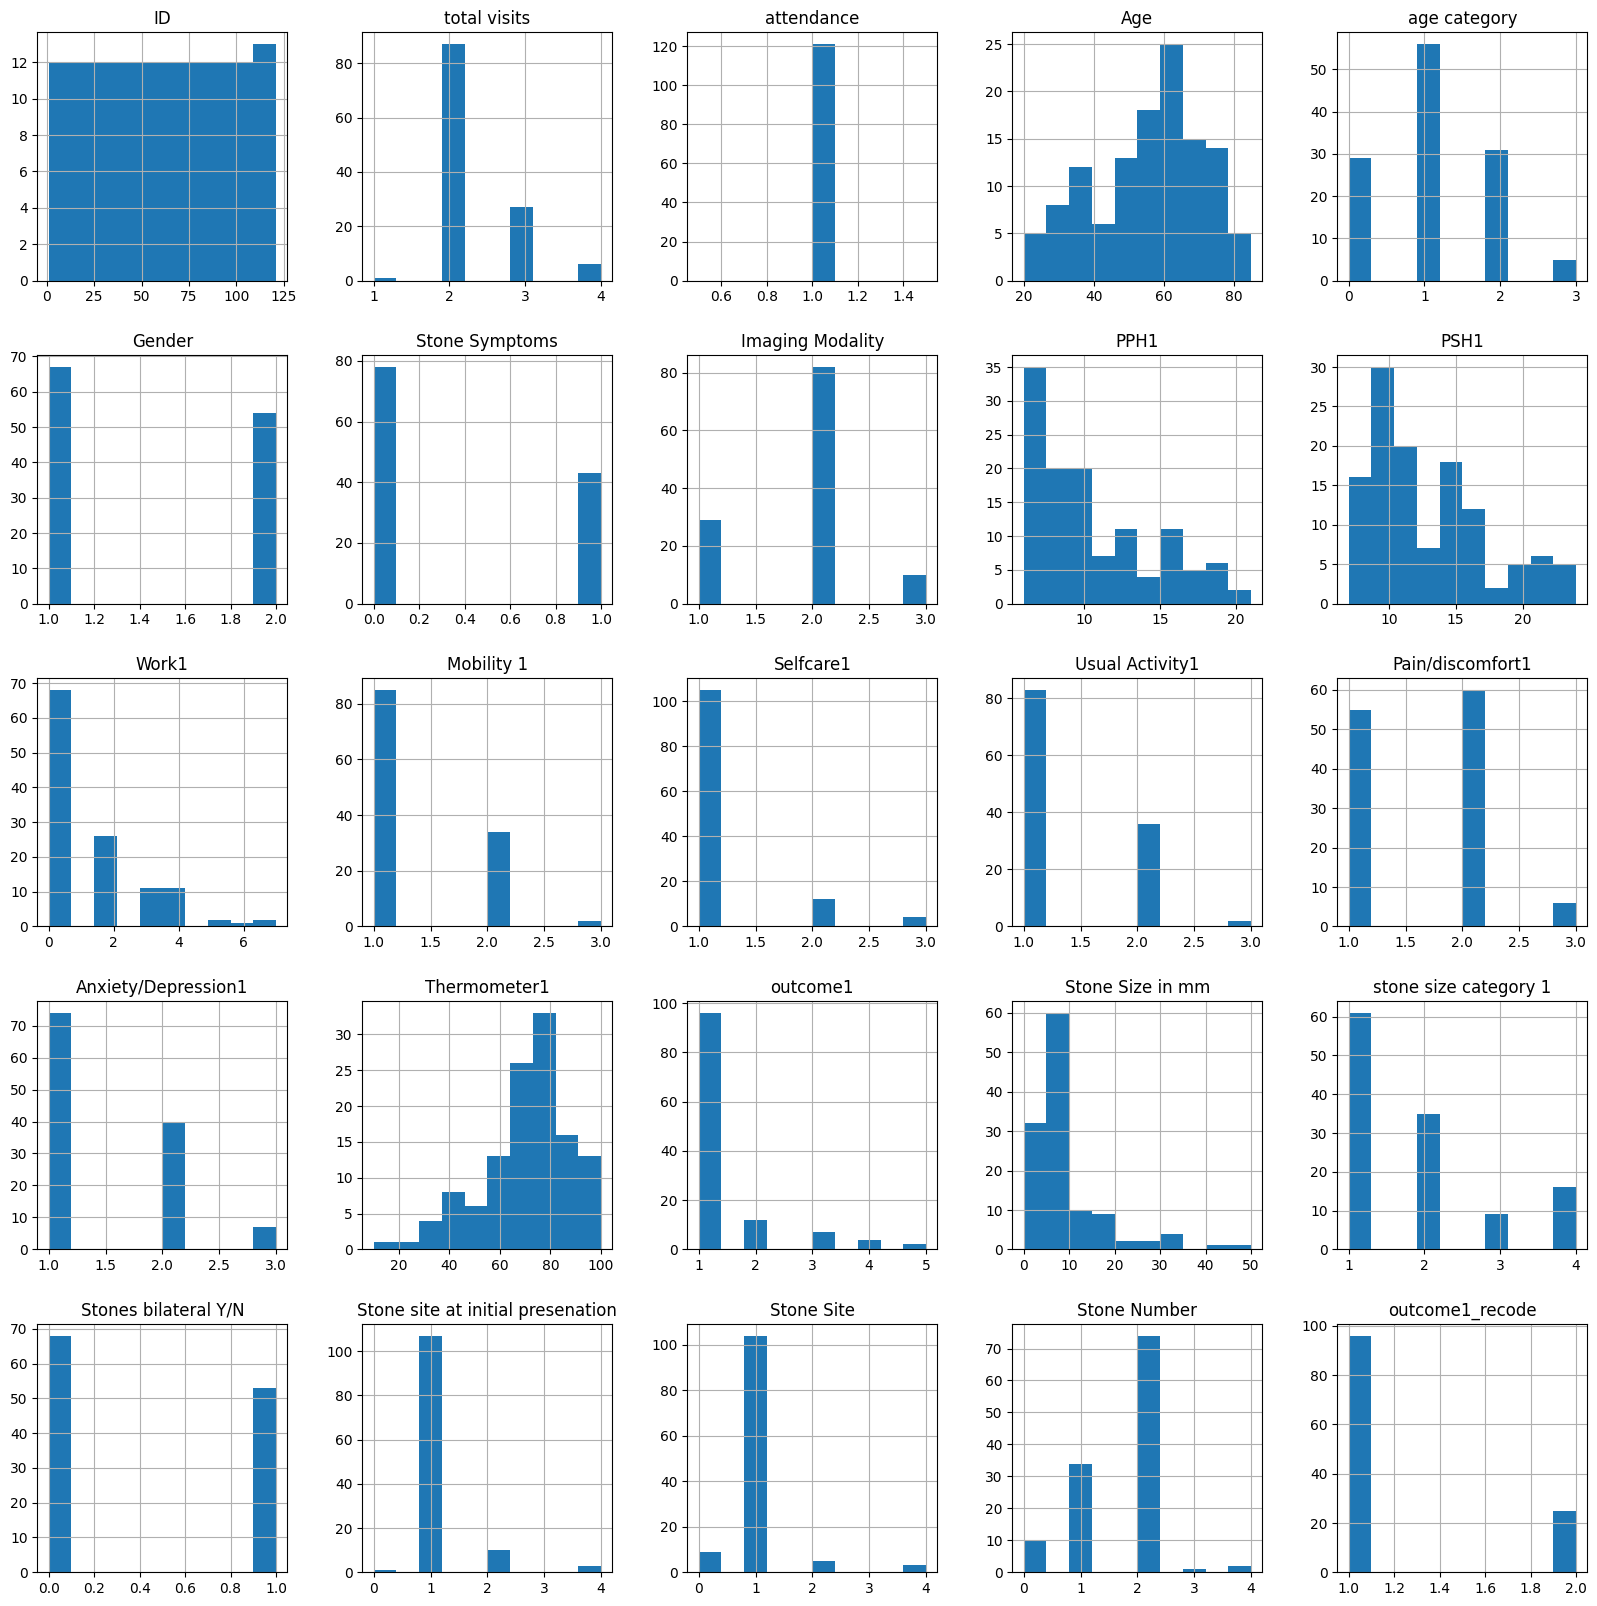

In [ ]:
numeric_df.hist(figsize=(20,20),bins=10)

In [ ]:
numeric_df = df_visit1_xa.select_dtypes(include=['number'])
correlations = numeric_df.corr()['outcome1_recode'].drop('outcome1_recode').abs()
high_corr_cols = correlations[correlations > 0.27].index.tolist()
print(high_corr_cols)


['Stone Symptoms', 'PPH1', 'PSH1', 'Usual Activity1', 'Pain/discomfort1', 'outcome1', 'Stone Size in mm', 'stone size category 1', 'Stone site at initial presenation', 'Stone Site']


In [ ]:
df_visit1_xa.head()

,ID,total visits,attendance,CLINIC Date,Age,age category,Gender,Stone Symptoms,Imaging Modality,PPH1,...,Outcome/Intervention,outcome1,Stone Size in mm,stone size category 1,Stones bilateral Y/N,Stone site at initial presenation,Stone Site,Stone Number,Comments,outcome1_recode
0,1,2,1,2022-01-27,58,1,1,1,1,15,...,ESWL,2,6.0,2,0,1,1,1,NaN,2
1,2,2,1,2023-10-13,60,1,1,1,1,7,...,follow up,1,8.0,2,0,1,1,2,NaN,1
2,3,2,1,2022-01-13,54,1,1,0,3,8,...,follow up,1,6.0,2,1,1,1,2,NaN,1
3,4,3,1,2021-04-23,51,1,1,1,2,9,...,ESWL,2,5.0,1,1,1,1,2,NaN,2
4,5,2,1,2023-09-02,30,0,1,0,2,9,...,follow up,1,2.0,1,0,1,1,2,NaN,1


In [ ]:

# columns_to_scale = ['PPH1', 'PSH1', 'Work1']
# df_visit1_xa[columns_to_scale] = scaler.fit_transform(df_visit1_xa[columns_to_scale])

In [ ]:
df_visit1_xa.columns

Index(['ID', 'total visits', 'attendance', 'CLINIC Date', 'Age',
       'age category', 'Gender', 'Stone Symptoms', 'Imaging Modality', 'PPH1',
       'PSH1', 'Work1', 'Mobility 1', 'Selfcare1', 'Usual Activity1',
       'Pain/discomfort1', 'Anxiety/Depression1', 'Thermometer1',
       'Outcome/Intervention', 'outcome1', 'Stone Size in mm',
       'stone size category 1', 'Stones bilateral Y/N',
       'Stone site at initial presenation', 'Stone Site', 'Stone Number',
       'Comments', 'outcome1_recode'],
      dtype='object')

In [ ]:
scaler = StandardScaler()
features1=['Stone Symptoms', 'PPH1', 'PSH1', 'Pain/discomfort1',
          'Work1', 'Stone site at initial presenation','Mobility 1'
          ,'Anxiety/Depression1','Thermometer1','Stones bilateral Y/N','Stone Site', 'Stone Number','stone size category 1'
          ,'Usual Activity1']
target = 'outcome1_recode'  
df_visit1_xa[features1] = scaler.fit_transform(df_visit1_xa[features1])


X = df_visit1_xa[features1]
y = df_visit1_xa[target]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Fit logistic regression
lr = LogisticRegression(
    C=0.1,
    class_weight="balanced",
    max_iter=500,
    penalty='l2',
    solver='lbfgs',
    random_state=42
)

lr.fit(X_train, y_train)

# Predict on test set
y_pred = lr.predict(X_test)

# Evaluation
print("Classification Report (Logistic Regression) before grid search:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: ROC-AUC (binary only or OvR)
if len(np.unique(y_test)) == 2:
    y_proba = lr.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    print(f"ROC AUC Score: {auc:.3f}")


Classification Report (Logistic Regression) before grid search:
               precision    recall  f1-score   support

           1       0.96      0.90      0.93        29
           2       0.70      0.88      0.78         8

    accuracy                           0.89        37
   macro avg       0.83      0.89      0.85        37
weighted avg       0.91      0.89      0.90        37

Confusion Matrix:
 [[26  3]
 [ 1  7]]
ROC AUC Score: 0.940


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],               # Regularization strength
    'penalty': ['l2'],                          # Try 'l1' if solver supports it
    'solver': ['liblinear', 'lbfgs'],           # Solvers
    'class_weight': [None, 'balanced'],         # Handle imbalance
    'max_iter': [100, 200, 500, 1000]
}

# Create logistic regression object
lr = LogisticRegression()

grid = GridSearchCV(lr, param_grid, cv=5, scoring='f1_weighted')  # Use scoring as needed
grid.fit(X_train, y_train)

print("Best score:", grid.best_score_)
print("Best parameters:", grid.best_params_)


Best score: 0.8614724736048265
Best parameters: {'C': 0.1, 'class_weight': None, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}


In [ ]:
# Fit logistic regression
lr = LogisticRegression(
    C=1,
    class_weight= None,
    max_iter=100,
    penalty='l2',
    solver='liblinear',
    random_state=42
)
lr.fit(X_train, y_train)

# Predict on test set
y_pred = lr.predict(X_test)

# Evaluation
print("Classification Report (Logistic Regression), with tuned parameters:\n",classification_report(
    y_test, y_pred,
    target_names=["Follow-up (1)", "Procedure (2)"]
))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: ROC-AUC (binary only or OvR)
if len(np.unique(y_test)) == 2:
    y_proba = lr.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    print(f"ROC AUC Score: {auc:.3f}")


Classification Report (Logistic Regression), with tuned parameters:
                precision    recall  f1-score   support

Follow-up (1)       0.93      0.97      0.95        29
Procedure (2)       0.86      0.75      0.80         8

     accuracy                           0.92        37
    macro avg       0.90      0.86      0.87        37
 weighted avg       0.92      0.92      0.92        37

Confusion Matrix:
 [[28  1]
 [ 2  6]]
ROC AUC Score: 0.948


In [ ]:
# Logistic Regression + SMOTE + CV
RANDOM_STATE = 42
N_SPLITS = 5

# Detect binary vs multiclass
classes = np.unique(y_train)
is_binary = (len(classes) == 2)

# Define scoring for CV
if is_binary:
    scoring = {
        "roc_auc": "roc_auc",
        "f1": "f1",
        "bal_acc": "balanced_accuracy",
        "precision": "precision",
        "recall": "recall",
    }
    lr_kwargs = dict(
        penalty="l2",
        C=1,
        solver="liblinear",
        max_iter=100,
        random_state=RANDOM_STATE
    )
else:
    scoring = {
        "f1_macro": "f1_macro",
        "f1_weighted": "f1_weighted",
        "bal_acc": "balanced_accuracy",
    }
    lr_kwargs = dict(
        penalty="l2",
        C=0.1,
        solver="lbfgs",
        max_iter=500,
        random_state=RANDOM_STATE,
        multi_class="ovr"   # OvR is usually more stable with imbalance
    )

# Build pipeline: SMOTE (fit-time only) -> Logistic Regression
pipe_smote_lr = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ("clf", LogisticRegression(class_weight=None, **lr_kwargs))
])

# ---- Cross-Validation on training data ----
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cv_res = cross_validate(
    pipe_smote_lr,
    X_train, y_train,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)

print("Logistic Regression + SMOTE — Cross-Validation (Train only)\n")
for k, v in cv_res.items():
    if k.startswith("test_"):
        metric = k.replace("test_", "")
        print(f"{metric:>15s}: mean={np.mean(v):.3f} | std={np.std(v):.3f}\n")

# ---- Fit on full training set and evaluate on hold-out test ----
pipe_smote_lr.fit(X_train, y_train)
y_pred_sm = pipe_smote_lr.predict(X_test)

print("Logistic Regression + SMOTE — Hold-out Evaluation (Test set)\n")
if is_binary:
    print("Classification Report:\n", classification_report(
        y_test, y_pred_sm, target_names=["Follow-up (1)", "Procedure (2)"]
    ))
else:
    print("Classification Report:\n", classification_report(y_test, y_pred_sm))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_sm))

if is_binary and hasattr(pipe_smote_lr.named_steps["clf"], "predict_proba"):
    y_proba_sm = pipe_smote_lr.named_steps["clf"].predict_proba(X_test)[:, 1]
    auc_sm = roc_auc_score(y_test, y_proba_sm)
    print(f"ROC AUC Score: {auc_sm:.3f}")



Logistic Regression + SMOTE — Cross-Validation (Train only)

        roc_auc: mean=0.919 | std=0.057

             f1: mean=0.880 | std=0.041

        bal_acc: mean=0.802 | std=0.089

      precision: mean=0.938 | std=0.053

         recall: mean=0.837 | std=0.097

Logistic Regression + SMOTE — Hold-out Evaluation (Test set)

Classification Report:
                precision    recall  f1-score   support

Follow-up (1)       0.96      0.93      0.95        29
Procedure (2)       0.78      0.88      0.82         8

     accuracy                           0.92        37
    macro avg       0.87      0.90      0.89        37
 weighted avg       0.92      0.92      0.92        37

Confusion Matrix:
 [[27  2]
 [ 1  7]]
ROC AUC Score: 0.935


Missing in test: 0 | Extra in test: 0
                              feature  mean_importance  std_importance
0                      Stone Symptoms         0.151207        0.063477
12              stone size category 1         0.057155        0.034909
1                                PPH1         0.025948        0.011190
10                         Stone Site         0.014397        0.014772
5   Stone site at initial presenation         0.010603        0.011508
4                               Work1         0.008879        0.010105
13                    Usual Activity1         0.007759        0.006950
9                Stones bilateral Y/N         0.005948        0.003940
3                    Pain/discomfort1         0.003190        0.018903
2                                PSH1         0.001466        0.002530
8                        Thermometer1         0.000690        0.001580
11                       Stone Number        -0.000776        0.003071
6                          Mobility 1  

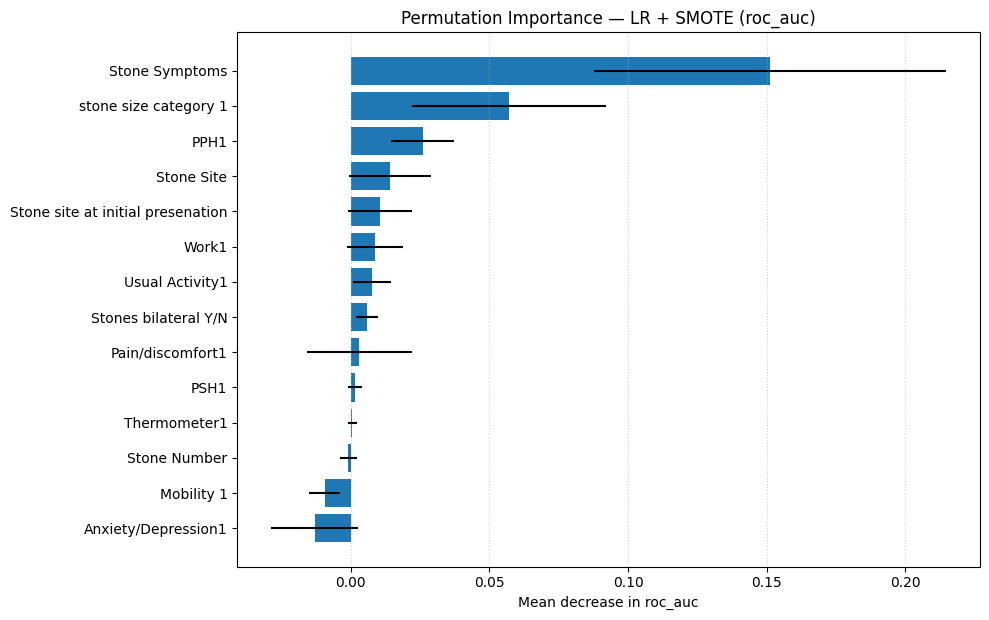

In [ ]:
# ============================================================================
# SECTION 11: PERMUTATION IMPORTANCE (Feature Importance Analysis)
# ============================================================================
# Analyze which features most impact model predictions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# 0) Scorer
scorer = "roc_auc" if (is_binary and hasattr(pipe_smote_lr.named_steps["clf"], "predict_proba")) else ("f1" if is_binary else "f1_macro")

# 1) Get the exact feature order the LR saw during fit
clf = pipe_smote_lr.named_steps["clf"]
expected = getattr(clf, "feature_names_in_", None)
if expected is None:
    raise RuntimeError("clf.feature_names_in_ is missing. Fit the pipeline with a pandas DataFrame so names persist.")

# 2) Build X for PI with identical columns & order
if not isinstance(X_test, pd.DataFrame):
    X_test = pd.DataFrame(X_test, columns=expected)  # assume same order if array
X_pi = X_test.reindex(columns=expected, fill_value=0)

# (Optional) quick sanity check
missing = [c for c in expected if c not in X_test.columns]
extra   = [c for c in X_test.columns if c not in expected]
print(f"Missing in test: {len(missing)} | Extra in test: {len(extra)}")

# 3) Permutation importance
pi = permutation_importance(
    pipe_smote_lr, X_pi, y_test,
    scoring=scorer,
    n_repeats=50,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

df_perm = pd.DataFrame({
    "feature": expected,
    "mean_importance": pi.importances_mean,
    "std_importance":  pi.importances_std
}).sort_values("mean_importance", ascending=False)

print(df_perm.head(25))

# 4) Plot
def plot_importances(df, title="", top_n=20, ax=None):
    d = df.sort_values("mean_importance", ascending=False).head(top_n).iloc[::-1]
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(d))))
    else:
        fig = ax.figure
    xerr = d.get("std_importance", None)
    ax.barh(d["feature"], d["mean_importance"], xerr=xerr)
    ax.set_title(title)
    ax.set_xlabel(f"Mean decrease in {scorer}")
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle=":", alpha=0.6)
    plt.tight_layout()
    return fig, ax

plot_importances(df_perm, title=f"Permutation Importance — LR + SMOTE ({scorer})", top_n=20)
plt.show()


Missing in test: 0 | Extra in test: 0
                              feature  mean_importance  std_importance
0                      Stone Symptoms         0.249691        0.094923
12              stone size category 1         0.153600        0.081141
1                                PPH1         0.127267        0.060389
3                    Pain/discomfort1         0.075539        0.052817
4                               Work1         0.071342        0.056252
13                    Usual Activity1         0.071075        0.041206
7                 Anxiety/Depression1         0.070015        0.059719
10                         Stone Site         0.048174        0.036096
5   Stone site at initial presenation         0.041865        0.031522
9                Stones bilateral Y/N         0.035294        0.036735
6                          Mobility 1         0.023598        0.025782
2                                PSH1        -0.004918        0.029184
8                        Thermometer1  

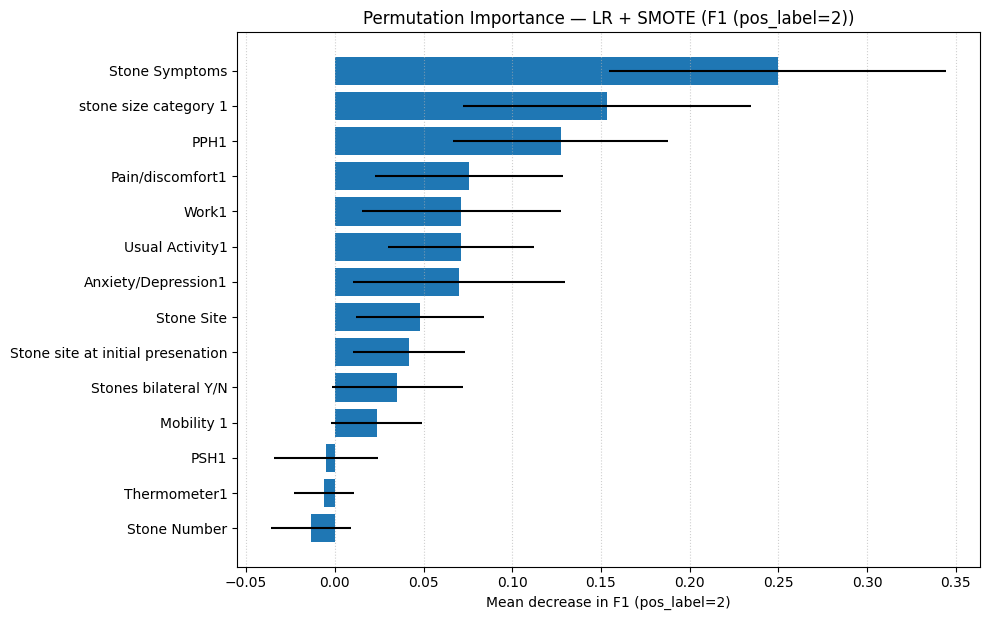

In [ ]:
# ============================================================================
# SECTION 11: PERMUTATION IMPORTANCE (Feature Importance Analysis)
# ============================================================================
# Analyze which features most impact model predictions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, f1_score

# --- Force F1 as the scorer ---
labels = np.unique(y_train)
if is_binary:
    # Make 'Procedure (2)' the positive class when labels are {1,2}; otherwise use the max label
    pos_label = 2 if set(labels) == {1, 2} else int(np.max(labels))
    scorer = make_scorer(f1_score, pos_label=pos_label)
    scorer_name = f"F1 (pos_label={pos_label})"
else:
    scorer = "f1_macro"   # or "f1_weighted" if you prefer support-weighting
    scorer_name = "F1 (macro)"

# --- Get the exact feature order the LR saw during fit ---
clf = pipe_smote_lr.named_steps["clf"]
expected = getattr(clf, "feature_names_in_", None)
if expected is None:
    raise RuntimeError("clf.feature_names_in_ is missing. Fit the pipeline with a pandas DataFrame so names persist.")

# --- Build X for PI with identical columns & order ---
if not isinstance(X_test, pd.DataFrame):
    X_test = pd.DataFrame(X_test, columns=expected)  # assume same order if array
X_pi = X_test.reindex(columns=expected, fill_value=0)

# (Optional) sanity check
missing = [c for c in expected if c not in X_test.columns]
extra   = [c for c in X_test.columns if c not in expected]
print(f"Missing in test: {len(missing)} | Extra in test: {len(extra)}")

# --- Permutation importance (using F1) ---
pi = permutation_importance(
    pipe_smote_lr, X_pi, y_test,
    scoring=scorer,
    n_repeats=50,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

df_perm = pd.DataFrame({
    "feature": expected,
    "mean_importance": pi.importances_mean,
    "std_importance":  pi.importances_std
}).sort_values("mean_importance", ascending=False)

print(df_perm.head(25))

# --- Plot ---
def plot_importances(df, title="", top_n=20, ax=None):
    d = df.sort_values("mean_importance", ascending=False).head(top_n).iloc[::-1]
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(d))))
    else:
        fig = ax.figure
    xerr = d.get("std_importance", None)
    ax.barh(d["feature"], d["mean_importance"], xerr=xerr)
    ax.set_title(title)
    ax.set_xlabel(f"Mean decrease in {scorer_name}")
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle=":", alpha=0.6)
    plt.tight_layout()
    return fig, ax

plot_importances(df_perm, title=f"Permutation Importance — LR + SMOTE ({scorer_name})", top_n=20)
plt.show()



Top permutation importances (F1, pos_label=1):
                               feature  mean_importance  std_importance
0                      Stone Symptoms         0.080809        0.034206
12              stone size category 1         0.052778        0.029754
1                                PPH1         0.033067        0.018766
13                    Usual Activity1         0.028040        0.014917
4                               Work1         0.027137        0.021935
3                    Pain/discomfort1         0.024366        0.019111
10                         Stone Site         0.020016        0.014884
7                 Anxiety/Depression1         0.018030        0.016926
5   Stone site at initial presenation         0.017834        0.014064
6                          Mobility 1         0.009802        0.010863
9                Stones bilateral Y/N         0.007840        0.008160
2                                PSH1        -0.001361        0.010958
8                        The

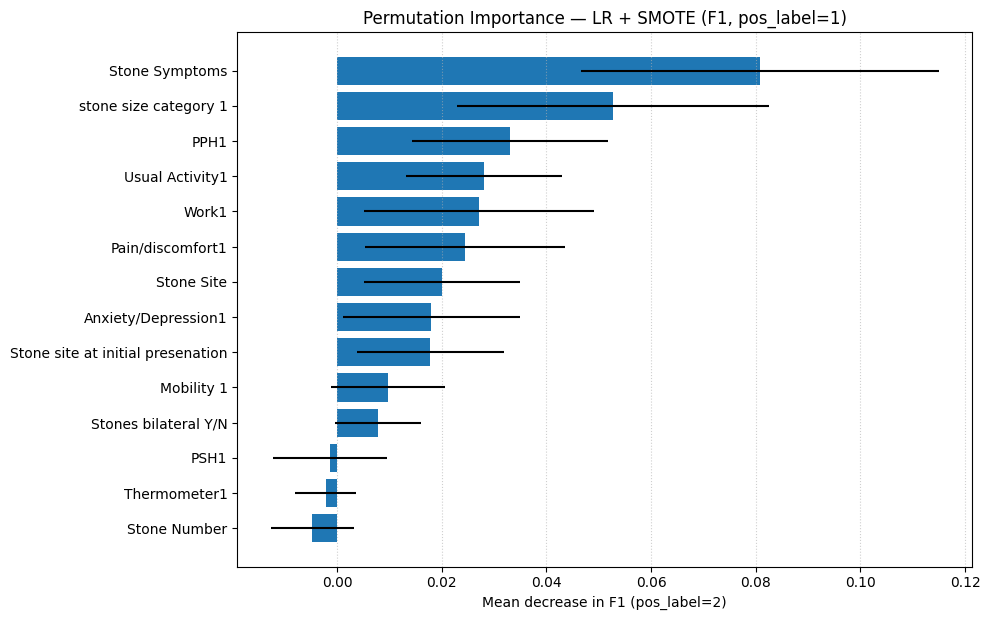

In [ ]:
# ============================================================================
# SECTION 11: PERMUTATION IMPORTANCE (Feature Importance Analysis)
# ============================================================================
# Analyze which features most impact model predictions
from sklearn.metrics import make_scorer, f1_score

# --- F1 scorer with pos_label=1 ---
scorer_pos1 = make_scorer(f1_score, pos_label=1)

# --- PI with F1 (pos_label=1) ---
pi_pos1 = permutation_importance(
    pipe_smote_lr, X_pi, y_test,
    scoring=scorer_pos1,
    n_repeats=50,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

df_perm_pos1 = pd.DataFrame({
    "feature": expected,
    "mean_importance": pi_pos1.importances_mean,
    "std_importance":  pi_pos1.importances_std
}).sort_values("mean_importance", ascending=False)

print("\nTop permutation importances (F1, pos_label=1):\n", df_perm_pos1.head(25))

# --- Plot ---
plot_importances(
    df_perm_pos1,
    title="Permutation Importance — LR + SMOTE (F1, pos_label=1)",
    top_n=20
)
plt.show()


In [ ]:
# ============================================================================
# SECTION 11: PERMUTATION IMPORTANCE (Feature Importance Analysis)
# ============================================================================
# Analyze which features most impact model predictions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer

# 0) Pick scorer from your earlier flag
scorer = "roc_auc" if is_binary else "f1_macro"

# 1) Start with EXACT hold-out features used in your test evaluation
X_pi = X_test.copy()  # DO NOT coerce with to_numeric (it can create NaNs)

# 2) If training used a specific column set (e.g., after get_dummies), align test to it
if isinstance(X_train, pd.DataFrame) and isinstance(X_test, pd.DataFrame):
    X_pi = X_pi.reindex(columns=X_train.columns, fill_value=0)

# 3) If the pipeline has no imputer and X has NaNs, impute ONLY for PI (non-destructive)
if isinstance(X_pi, pd.DataFrame) and X_pi.isna().any().any():
    imp = SimpleImputer(strategy="median")
    X_pi = pd.DataFrame(imp.fit_transform(X_pi), columns=X_test.columns, index=X_test.index)

# 4) Feature names for plotting
feat_names = X_pi.columns.tolist() if isinstance(X_pi, pd.DataFrame) else [f"f{i}" for i in range(X_pi.shape[1])]

# 5) Permutation importance (on the already-fitted pipe_smote_lr)
pi = permutation_importance(
    pipe_smote_lr,
    X_pi,
    y_test,
    scoring=scorer,
    n_repeats=50,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

df_perm = pd.DataFrame({
    "feature": feat_names,
    "mean_importance": pi.importances_mean,
    "std_importance":  pi.importances_std
}).sort_values("mean_importance", ascending=False)

print(df_perm.head(25))

# 6) Plot helper
def plot_importances(df, title="", top_n=20, ax=None):
    d = df.sort_values("mean_importance", ascending=False).head(top_n).iloc[::-1]
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(d))))
    else:
        fig = ax.figure
    xerr = d.get("std_importance", None)
    ax.barh(d["feature"], d["mean_importance"], xerr=xerr)
    ax.set_title(title)
    ax.set_xlabel(f"Mean decrease in {scorer}")
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle=":", alpha=0.6)
    plt.tight_layout()
    return fig, ax

plot_importances(df_perm, title=f"Permutation Importance — LR + SMOTE ({scorer})", top_n=20)
plt.show()


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Anxiety/Depression1
- Mobility 1
- PPH1
- PSH1
- Pain/discomfort1
- ...
Feature names seen at fit time, yet now missing:
- Anxiety/Depression2
- Changes from prior imaging
- Mobility 2
- PPH2
- PSH2
- ...


In [ ]:
# ============================================================================
# XGBOOST WITH SMOTE
# ============================================================================
# --- 0) Make sure X is numeric and aligned ---
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test,  drop_first=True)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)


# --- 1) y to 1-D and remap {1,2} -> {0,1} ---
y_train_mc = (np.asarray(y_train).reshape(-1) - 1).astype(int)
y_test_mc  = (np.asarray(y_test).reshape(-1)  - 1).astype(int)

# --- 2) XGBoost classifier (binary via multi:softprob with num_class=2) ---
xgb_mc = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=2,
    eval_metric='mlogloss',
    learning_rate=0.1,
    max_depth=5,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

# --- 3) Use numpy float32 arrays to avoid .dtype on DataFrame ---
Xtr = X_train.to_numpy(dtype=np.float32)
Xte = X_test.to_numpy(dtype=np.float32)

xgb_mc.fit(Xtr, y_train_mc)

# --- 4) Predict ---
proba = xgb_mc.predict_proba(Xte)                 # shape: (n_samples, 2)
y_pred_mc = proba.argmax(axis=1).astype(int)      # 0/1
y_pred = (y_pred_mc + 1).astype(int)              # back to {1,2}

# --- 5) Report ---
print("Stage 1 - XGBoost Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["Follow-up (1)", "Procedure (2)"]
))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Stage 1 - XGBoost Classification Report:
               precision    recall  f1-score   support

Follow-up (1)       0.90      0.97      0.93        29
Procedure (2)       0.83      0.62      0.71         8

     accuracy                           0.89        37
    macro avg       0.87      0.80      0.82        37
 weighted avg       0.89      0.89      0.89        37

Confusion Matrix:
 [[28  1]
 [ 3  5]]


In [ ]:
# ============================================================================
# XGBOOST WITH SMOTE
# ============================================================================

# Convert to float32 ndarray for speed/stability
Xtr = X_train.to_numpy(dtype=np.float32)
Xte = X_test.to_numpy(dtype=np.float32)

# --- Class imbalance weight (neg/pos) ---
pos = (y_train_mc == 1).sum()
neg = (y_train_mc == 0).sum()
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

# --- Base model (binary:logistic) ---
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    tree_method="hist",    # fast on CPU
    n_jobs=-1
)

# --- Hyperparameter grid (tweak as needed) ---
param_grid = {
    "max_depth":        [3, 5, 7],
    "n_estimators":     [200, 300, 400],
    "learning_rate":    [0.01, 0.1],
    "subsample":        [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma":            [0, 1],              # split regularization
    # fix imbalance weight but you can also grid it lightly if you want
    "scale_pos_weight": [scale_pos_weight]
}

# --- Use F1 (binary) to select best model ---
f1_scorer = make_scorer(f1_score, average="binary")

grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring=f1_scorer,
    cv=5,            # StratifiedKFold by default for classifiers
    n_jobs=-1,
    verbose=1
)

# --- Run search ---
grid.fit(Xtr, y_train_mc)

print("Best params:", grid.best_params_)
print("Best CV F1:", round(grid.best_score_, 3))

# --- Evaluate best model on the hold-out set ---
best_xgb = grid.best_estimator_
y_pred_mc = best_xgb.predict(Xte)                 # 0/1
y_pred = (y_pred_mc + 1).astype(int)              # back to {1,2} for your reports

print("\nClassification Report (XGB, tuned):")
print(classification_report(
    y_test, y_pred,
    target_names=["Follow-up (1)", "Procedure (2)"]
))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# # --- (Optional) Feature importance table ---
# importances = pd.Series(best_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
# print("\nTop 15 features:\n", importances.head(15))


Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Best params: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 300, 'scale_pos_weight': np.float64(3.9411764705882355), 'subsample': 0.8}
Best CV F1: 0.658

Classification Report (XGB, tuned):
               precision    recall  f1-score   support

Follow-up (1)       0.90      0.90      0.90        29
Procedure (2)       0.62      0.62      0.62         8

     accuracy                           0.84        37
    macro avg       0.76      0.76      0.76        37
 weighted avg       0.84      0.84      0.84        37

Confusion Matrix:
 [[26  3]
 [ 3  5]]


In [ ]:
# ============================================================================
# XGBOOST WITH SMOTE
# ============================================================================
# ==========================================
# XGBoost + SMOTE + Stratified CV (Binary)
# ==========================================
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_recall_curve)

RANDOM_STATE = 42
N_SPLITS = 5

# --- Ensure numeric (same as your current helper) ---
def to_float32(X):
    if isinstance(X, pd.DataFrame):
        return X.apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float32)
    return np.asarray(X, dtype=np.float32)

Xtr = to_float32(X_train)
Xte = to_float32(X_test)

# --- Map labels {1,2}->{0,1} if needed ---
ytr = np.asarray(y_train).astype(int)
yte = np.asarray(y_test).astype(int)

if np.array_equal(np.unique(ytr), np.array([1, 2])):
    ytr_bin = (ytr - 1)
    yte_bin = (yte - 1)
    target_names = ["Follow-up (1)", "Intervention (2)"]
else:
    ytr_bin, yte_bin = ytr, yte
    target_names = None

# --- XGBoost params (NO class weighting here; SMOTE handles balance) ---
xgb_params = dict(
    objective="binary:logistic",
    eval_metric="auc",          # use "aucpr" if very imbalanced
    learning_rate=0.1,
    max_depth=5,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=1.0,
    gamma=0,
    min_child_weight=1,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# --- Pipeline: SMOTE (train folds only) -> XGB ---
pipe_xgb_smote = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ("xgb", XGBClassifier(**xgb_params))
])

# --- Stratified CV (on training data) ---
scoring = {
    "roc_auc": "roc_auc",
    "f1": "f1",
    "bal_acc": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall"
}
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cv_res = cross_validate(
    pipe_xgb_smote, Xtr, ytr_bin,
    scoring=scoring, cv=cv,
    n_jobs=-1, return_train_score=False
)

print("="*70)
print("XGBoost + SMOTE — Cross-Validation (Train only)")
print("="*70)
for k, v in cv_res.items():
    if k.startswith("test_"):
        metric = k.replace("test_", "")
        print(f"{metric:>15s}: mean={np.mean(v):.3f} | std={np.std(v):.3f}")
print("="*70, "\n")

# --- Fit on full training set (SMOTE applied inside pipeline) ---
pipe_xgb_smote.fit(Xtr, ytr_bin)

# --- Hold-out evaluation + threshold tuning (maximize F1) ---
proba = pipe_xgb_smote.predict_proba(Xte)[:, 1]
prec, rec, thr = precision_recall_curve(yte_bin, proba)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = np.nanargmax(f1s)
best_thr = thr[max(best_idx - 1, 0)] if len(thr) > 0 else 0.5

y_pred = (proba >= best_thr).astype(int)

print("="*70)
print("XGBoost + SMOTE — Hold-out Evaluation (Test set)")
print("="*70)
print(f"Best F1 threshold: {best_thr:.3f}")
print("Classification Report:\n", classification_report(yte_bin, y_pred, target_names=target_names))
print("Confusion Matrix:\n", confusion_matrix(yte_bin, y_pred))
print(f"ROC AUC: {roc_auc_score(yte_bin, proba):.3f}")
print("="*70)


XGBoost + SMOTE — Cross-Validation (Train only)
        roc_auc: mean=0.901 | std=0.104
             f1: mean=0.610 | std=0.187
        bal_acc: mean=0.755 | std=0.110
      precision: mean=0.633 | std=0.221
         recall: mean=0.600 | std=0.178

XGBoost + SMOTE — Hold-out Evaluation (Test set)
Best F1 threshold: 0.056
Classification Report:
                   precision    recall  f1-score   support

   Follow-up (1)       1.00      0.83      0.91        29
Intervention (2)       0.62      1.00      0.76         8

        accuracy                           0.86        37
       macro avg       0.81      0.91      0.83        37
    weighted avg       0.92      0.86      0.87        37

Confusion Matrix:
 [[24  5]
 [ 0  8]]
ROC AUC: 0.948


In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

# 1) One-hot encode & align
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  drop_first=True)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join="left", axis=1, fill_value=0)

# 2) Impute
imp = SimpleImputer(strategy="median")
X_train_imp = imp.fit_transform(X_train_enc)
X_test_imp  = imp.transform(X_test_enc)

# 3) y → 1-D ints
y_train_vec = pd.Series(y_train).to_numpy().ravel().astype(int)
y_test_vec  = pd.Series(y_test).to_numpy().ravel().astype(int)

# 4) Train RF (class-weighted)
rf_sm = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    class_weight="balanced",  # try "balanced_subsample" as an alternative
    n_jobs=-1,
    random_state=42,
)
rf_sm.fit(X_train_imp, y_train_vec)

# 5) Evaluate
y_pred_rf = rf_sm.predict(X_test_imp)
print("Random Forest (class-weighted, no SMOTE) — Classification Report")
print(classification_report(y_test_vec, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test_vec, y_pred_rf))

# Optional: ROC-AUC if binary
if np.unique(y_test_vec).size == 2:
    y_proba = rf_sm.predict_proba(X_test_imp)[:, 1]
    print("ROC AUC:", roc_auc_score(y_test_vec, y_proba))


Random Forest (class-weighted, no SMOTE) — Classification Report
              precision    recall  f1-score   support

           1       0.90      0.97      0.93        29
           2       0.83      0.62      0.71         8

    accuracy                           0.89        37
   macro avg       0.87      0.80      0.82        37
weighted avg       0.89      0.89      0.89        37

Confusion Matrix:
 [[28  1]
 [ 3  5]]
ROC AUC: 0.9482758620689655


In [ ]:
# --- 1) One-hot encode categoricals & align columns (same as baseline) ---
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  drop_first=True)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join="left", axis=1, fill_value=0)

# --- 2) Impute missing values BEFORE SMOTE (SMOTE can't handle NaNs) ---
imp = SimpleImputer(strategy="median")
X_train_imp = imp.fit_transform(X_train_enc)
X_test_imp  = imp.transform(X_test_enc)

# --- 3) y as 1D ---
y_train_vec = pd.Series(y_train).to_numpy().ravel()
y_test_vec  = pd.Series(y_test).to_numpy().ravel()

# --- 4) Choose safe k_neighbors based on smallest class in y_train ---
counts = Counter(y_train_vec)
minority_count = min(counts.values())
k_neighbors = max(1, min(5, minority_count - 1))   # must be < minority_count

print(f"Class counts (train) before SMOTE: {counts}")
print(f"Using SMOTE with k_neighbors={k_neighbors}")

# --- 5) Apply SMOTE to TRAINING data only ---
smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_res, y_train_res = smote.fit_resample(X_train_imp, y_train_vec)

print(f"Class counts (train) after  SMOTE: {Counter(y_train_res)}")

# --- 6) Train Random Forest on resampled data ---
rf_sm = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
rf_sm.fit(X_train_res, y_train_res)

# --- 7) Evaluate on untouched test set ---
y_pred_rf_sm = rf_sm.predict(X_test_imp)
print("Random Forest + SMOTE — Classification Report")
print(classification_report(y_test_vec, y_pred_rf_sm))
print("Confusion Matrix:\n", confusion_matrix(y_test_vec, y_pred_rf_sm))


Class counts (train) before SMOTE: Counter({np.int64(1): 67, np.int64(2): 17})
Using SMOTE with k_neighbors=5
Class counts (train) after  SMOTE: Counter({np.int64(2): 67, np.int64(1): 67})
Random Forest + SMOTE — Classification Report
              precision    recall  f1-score   support

           1       0.90      0.93      0.92        29
           2       0.71      0.62      0.67         8

    accuracy                           0.86        37
   macro avg       0.81      0.78      0.79        37
weighted avg       0.86      0.86      0.86        37

Confusion Matrix:
 [[27  2]
 [ 3  5]]


In [ ]:
# ============================================================================
# RANDOM FOREST WITH GRID SEARCH & SMOTE
# ============================================================================
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score

# y as 1D
y_train_vec = pd.Series(y_train).to_numpy().ravel()
y_test_vec  = pd.Series(y_test).to_numpy().ravel()

# ---- choose n_splits safely for small data ----
# each fold must contain at least 1 sample of each class
_, class_counts = np.unique(y_train_vec, return_counts=True)
safe_splits = max(2, min(5, class_counts.min()))  # up to 5, but not more than the minority count

# ---- pipeline (impute within CV) ----
pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("rf",  RandomForestClassifier(random_state=42, n_jobs=-1))
])

# ---- tight grid for small data ----
param_grid = {
    "rf__n_estimators":      [200, 400],        # keep modest to avoid variance from many trees
    "rf__max_depth":         [None, 10],     # shallow-ish trees generalize better on small N
    "rf__min_samples_split": [2, 5],
    "rf__min_samples_leaf":  [1, 2],
    "rf__max_features":      ["sqrt", "log2"],
    "rf__bootstrap":         [True],
    "rf__class_weight":      [None, "balanced"] # try both; often helps on imbalance
}

# ---- repeated stratified CV to reduce variance ----
cv = RepeatedStratifiedKFold(n_splits=safe_splits, n_repeats=5, random_state=42)

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring={"f1_macro": "f1_macro", "bal_acc": "balanced_accuracy"},
    refit="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# NOTE: pass the encoded matrices; imputation happens *inside* CV
gs.fit(X_train_enc, y_train_vec)

print("Best params:", gs.best_params_)
print("Best CV macro-F1: {:.3f}".format(gs.best_score_))

# ---- test-set evaluation ----
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test_enc)

print("\nRandomForest (tuned) — Test Results")
print("Balanced Accuracy: {:.3f}".format(balanced_accuracy_score(y_test_vec, y_pred)))
print("Macro F1: {:.3f}".format(f1_score(y_test_vec, y_pred, average='macro')))
print("\nClassification Report:\n", classification_report(y_test_vec, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_vec, y_pred))


Fitting 25 folds for each of 64 candidates, totalling 1600 fits
Best params: {'rf__bootstrap': True, 'rf__class_weight': 'balanced', 'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 400}
Best CV macro-F1: 0.776

RandomForest (tuned) — Test Results
Balanced Accuracy: 0.761
Macro F1: 0.761

Classification Report:
               precision    recall  f1-score   support

           1       0.90      0.90      0.90        29
           2       0.62      0.62      0.62         8

    accuracy                           0.84        37
   macro avg       0.76      0.76      0.76        37
weighted avg       0.84      0.84      0.84        37

Confusion Matrix:
 [[26  3]
 [ 3  5]]


In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# --- 1) One-hot encode categoricals & align columns ---
Xtr = pd.get_dummies(X_train, drop_first=True)
Xte = pd.get_dummies(X_test, drop_first=True)
Xtr, Xte = Xtr.align(Xte, join="left", axis=1, fill_value=0)

# --- 2) Impute missing values ---
imp = SimpleImputer(strategy="median")
Xtr_imp = imp.fit_transform(Xtr)
Xte_imp = imp.transform(Xte)

# --- 3) y to 1D arrays ---
ytr = pd.Series(y_train).to_numpy().ravel()
yte = pd.Series(y_test).to_numpy().ravel()

# --- 4) Train Random Forest with balanced class weights ---
rf_bal = RandomForestClassifier(
    n_estimators=600,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_bal.fit(Xtr_imp, ytr)

# --- 5) Predictions & probabilities ---
yp = rf_bal.predict(Xte_imp)
proba = rf_bal.predict_proba(Xte_imp)[:, 1]

# --- 6) Evaluation ---
print("Random Forest (class_weight=balanced)")
print(classification_report(yte, yp))
print("Confusion Matrix:\n", confusion_matrix(yte, yp))
print("ROC AUC:", roc_auc_score(yte, proba))
print("PR AUC :", average_precision_score(yte, proba))


Random Forest (class_weight=balanced)
              precision    recall  f1-score   support

           1       0.90      0.97      0.93        29
           2       0.83      0.62      0.71         8

    accuracy                           0.89        37
   macro avg       0.87      0.80      0.82        37
weighted avg       0.89      0.89      0.89        37

Confusion Matrix:
 [[28  1]
 [ 3  5]]
ROC AUC: 0.9482758620689655
PR AUC : 0.6031748668685379


In [ ]:
# ============================================================================
# SECTION 11: PERMUTATION IMPORTANCE (Feature Importance Analysis)
# ============================================================================
# Analyze which features most impact model predictions
# # --- Import(s)
# import numpy as np
# import pandas as pd
# from sklearn.inspection import permutation_importance
# import matplotlib.pyplot as plt

# # helper: tidy bar plot
# def plot_importances(df_imp, title, top_n=20):
#     df_imp = df_imp.sort_values('mean_importance', ascending=True).tail(top_n)
#     ax = df_imp.plot(kind='barh', x='feature', y='mean_importance', xerr='std_importance', legend=False, figsize=(7, 6))
#     ax.set_xlabel("Permutation importance (Δscore)")
#     ax.set_ylabel("")
#     ax.set_title(title)
#     plt.tight_layout()
#     plt.show()

# # EXAMPLE USAGE:
# # Assume you already have: model_rf (fitted), X_test, y_test, feature_names = X_test.columns
# # IMPORTANT: run permutation on the FINAL fitted model; never refit inside this step.
# result = permutation_importance(
#     estimator=lr,
#     X=X_test,
#     y=y_test,
#     scoring="f1_macro",     # choose metric you care about (accuracy, f1_macro, balanced_accuracy, etc.)
#     n_repeats=30,
#     random_state=42,
#     n_jobs=-1
# )

# df_perm = pd.DataFrame({
#     "feature": features,
#     "mean_importance": result.importances_mean,
#     "std_importance": result.importances_std
# })

# plot_importances(df_perm, title="Permutation Importance ", top_n=20)
# df_perm.sort_values("mean_importance", ascending=False).head(25)


In [ ]:
# ============================================================================
# PROCESSING VISIT-2 DATA
# ============================================================================
# Count missing values in each column
missing_counts = df_visit2_xa.isnull().sum()

# Filter to show only columns with missing values
missing_counts = missing_counts[missing_counts > 0]

# Display the result
print("Missing values in df_visit1:")
print(missing_counts)
# df_visit2.shape

Missing values in df_visit1:
Mobility 2              1
Selfcare2               1
Usual Activity2         1
Pain/discomfort2        1
Anxiety/Depression2     2
Thermometer2            6
Stone Number.1          1
Comments.1             77
dtype: int64


In [ ]:
# stage2

In [ ]:
# ============================================================================
# PROCESSING VISIT-2 DATA
# ============================================================================
df_visit2_xa['Mobility 2'].fillna(df_visit2_xa['Mobility 2'].mode()[0], inplace=True)
df_visit2_xa['Selfcare2'].fillna(df_visit2_xa['Selfcare2'].mode()[0], inplace=True)
df_visit2_xa['Usual Activity2'].fillna(df_visit2_xa['Usual Activity2'].mode()[0], inplace=True)
df_visit2_xa['Pain/discomfort2'].fillna(df_visit2_xa['Pain/discomfort2'].mode()[0], inplace=True)
df_visit2_xa['Anxiety/Depression2'].fillna(df_visit2_xa['Anxiety/Depression2'].mode()[0], inplace=True)
df_visit2_xa['Stone Number.1'].fillna(df_visit2_xa['Stone Number.1'].mode()[0], inplace=True)
df_visit2_xa['Thermometer2'].fillna(df_visit2_xa['Thermometer2'].mean(), inplace=True)
# df_visit2_xa.drop(columns='Comments.1',inplace=True)
"""
Missing values in df_visit1:
Mobility 1              4
Selfcare1               3
Usual Activity1         3
Pain/discomfort1        4
Anxiety/Depression1     3
Thermometer1            6
Comments               58"""


C:\Users\umar0\AppData\Local\Temp\ipykernel_29852\3833754059.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_visit2_xa['Mobility 2'].fillna(df_visit2_xa['Mobility 2'].mode()[0], inplace=True)
C:\Users\umar0\AppData\Local\Temp\ipykernel_29852\3833754059.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

'\nMissing values in df_visit1:\nMobility 1              4\nSelfcare1               3\nUsual Activity1         3\nPain/discomfort1        4\nAnxiety/Depression1     3\nThermometer1            6\nComments               58'

In [ ]:
# ============================================================================
# PROCESSING VISIT-2 DATA
# ============================================================================
df_visit2_xa.columns

Index(['total visits.1', 'attendance.1', 'CLINIC Date 2', 'Age.1',
       'age category.1', 'Gender.1', 'Stone Symptoms.1', 'Imaging Modality.1',
       'PPH2', 'PSH2', 'Significant change in score', 'Work2', 'Mobility 2',
       'Selfcare2', 'Usual Activity2', 'Pain/discomfort2',
       'Anxiety/Depression2', 'Thermometer2', 'Outcome/Intervention2',
       'outcome2', 'outcome2.1', 'Stone Size in mm.1', 'stone size category 2',
       'Stones bilateral Y/N.1', 'Stone Site.1', 'Changes from prior imaging',
       'Stone Number.1', 'Comments.1', 'outcome2_recode'],
      dtype='object')

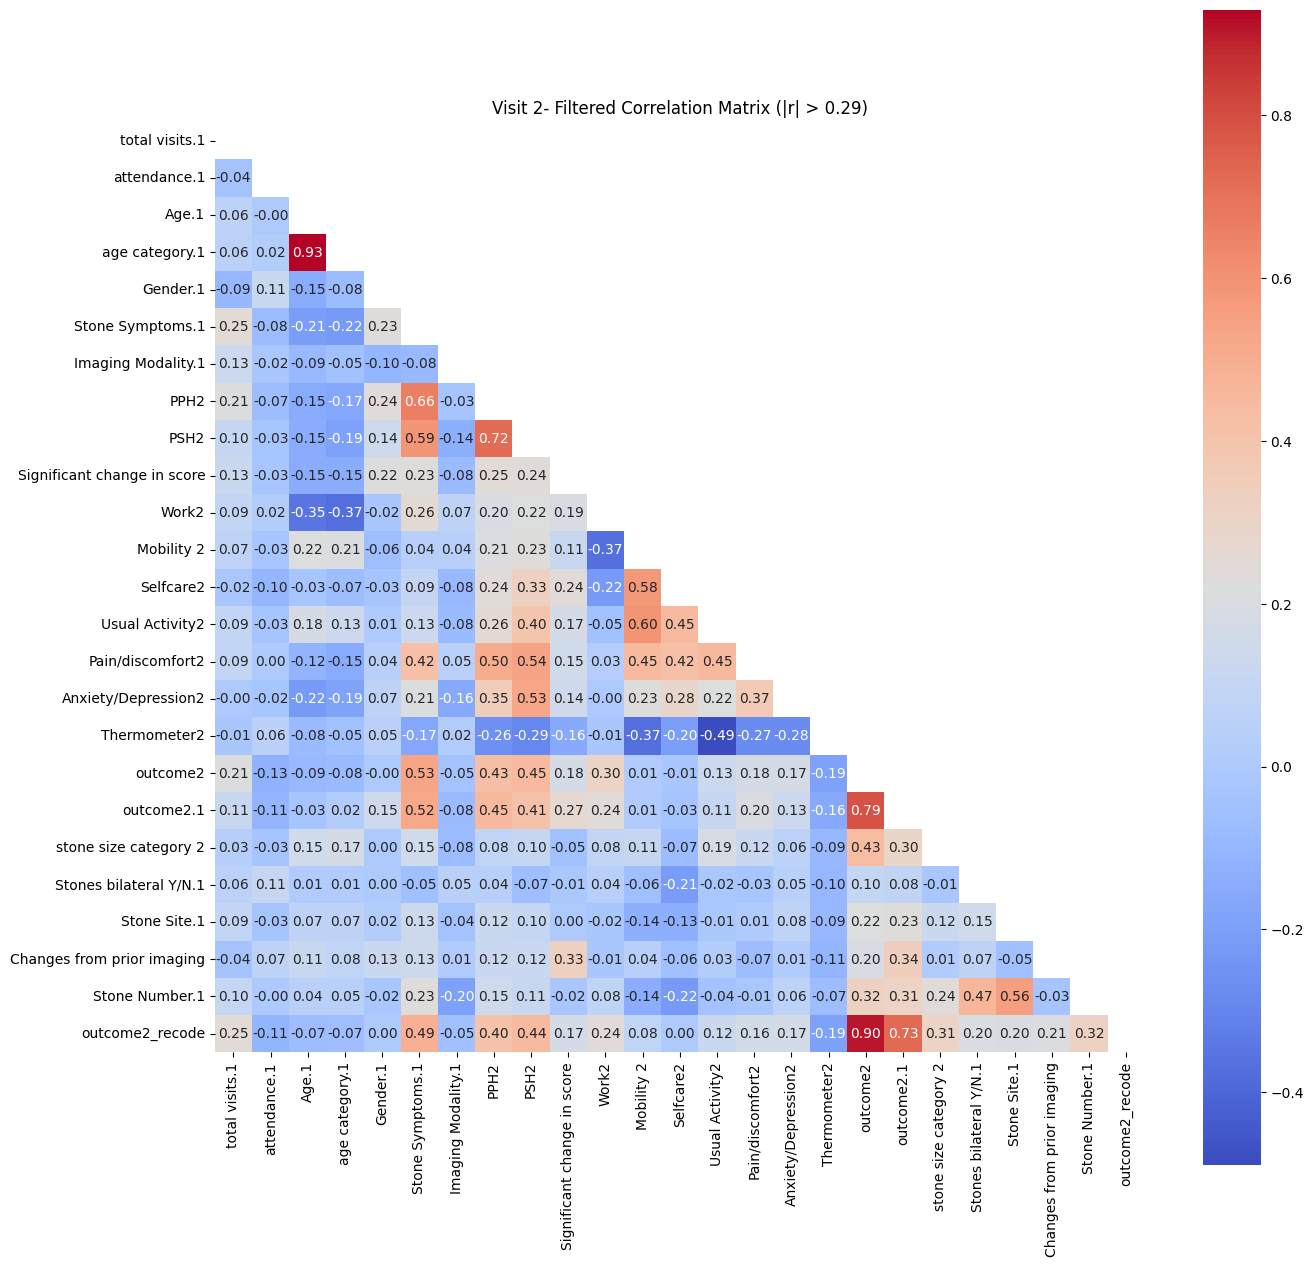

In [ ]:
# ============================================================================
# PROCESSING VISIT-2 DATA
# ============================================================================
# Reuse the numeric DataFrame from before
numeric_df = df_visit2_xa.select_dtypes(include=['number'])

# Compute the correlation matrix
corr_matrix = numeric_df.corr().abs()

# Find columns with any correlation > 0.35 (excluding self-correlation)
relevant_cols = corr_matrix.columns[(corr_matrix > 0.29).any() ]

# Filter the correlation matrix to include only those columns
filtered_corr = numeric_df[relevant_cols].corr()

# Mask the upper triangle
mask = np.triu(np.ones_like(filtered_corr, dtype=bool))

# Plot the reduced correlation matrix
plt.figure(figsize=(15, 15))
sns.heatmap(filtered_corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Visit 2- Filtered Correlation Matrix (|r| > 0.29)")
plt.show()


In [ ]:
# ============================================================================
# PROCESSING VISIT-2 DATA
# ============================================================================
numeric_df = df_visit2_xa.select_dtypes(include=['number'])
correlations = numeric_df.corr()['outcome2_recode'].drop('outcome2_recode').abs()
high_corr_cols = correlations[correlations > 0.27].index.tolist()
print(high_corr_cols)


['Stone Symptoms.1', 'PPH2', 'PSH2', 'outcome2', 'outcome2.1', 'stone size category 2', 'Stone Number.1']


In [ ]:
# corr_matrix = numeric_df.corr().abs()

# high_corr_features = corr_matrix.columns[
#     (corr_matrix > 0.29).any()
# ]

# df_high_corr = numeric_df[high_corr_features].copy()
# print("Selected features:\n", df_high_corr.columns.tolist())

In [ ]:
# ============================================================================
# PROCESSING VISIT-2 DATA
# ============================================================================
df_visit2_xa['outcome1']=df_visit1_xa['outcome1']

In [ ]:
# ============================================================================
# PROCESSING VISIT-2 DATA
# ============================================================================
scaler = StandardScaler()
columns_to_scale = ['PPH2', 'PSH2', 'Work2','Thermometer2']
df_visit2_xa[columns_to_scale] = scaler.fit_transform(df_visit2_xa[columns_to_scale])

In [ ]:
#'Stone Symptoms', 'PPH1', 'PSH1', 'Pain/discomfort1',
        #   'Work1', 'stone size category 1', 'Stone site at initial presenation','Mobility 1'
        #   ,'Anxiety/Depression1','Thermometer1','Stones bilateral Y/N','Stone Site', 'Stone Number','stone size category 1'
        #   ,'Usual Activity1'

In [ ]:
# ============================================================================
# PROCESSING VISIT-2 DATA
# ============================================================================

# features=['Age.1', 'Gender.1', 'Stone Symptoms.1',
#           'Imaging Modality.1', 'PPH2', 'PSH2', 'Significant change in score', 'Work2', 'Mobility 2',
#           'Selfcare2', 'Usual Activity2', 'Pain/discomfort2', 'Anxiety/Depression2', 'Thermometer_bin2',  
#           'stone size category 2', 'Stones bilateral Y/N.1', 'Stone Site.1', 'Changes from prior imaging', 
#           'Stone Number.1','outcome1']
scaler = StandardScaler()

features2=['Stone Symptoms.1', 'PPH2', 'PSH2', 'stone size category 2', 
            'Stone Number.1', 'Work2','Thermometer2',
             'Pain/discomfort2', 'Mobility 2'
        ,'Anxiety/Depression2','Stones bilateral Y/N.1','Stone Site.1', 'Changes from prior imaging'
         ,'Usual Activity2','outcome1']
df_visit2_xa[features2] = scaler.fit_transform(df_visit2_xa[features2])
target = 'outcome2_recode'  

X2 = df_visit2_xa[features2]
y2 = df_visit2_xa[target]


In [ ]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.30, stratify=y2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],               # Regularization strength
    'penalty': ['l2'],                          # Try 'l1' if solver supports it
    'solver': ['liblinear', 'lbfgs'],           # Solvers
    'class_weight': [None, 'balanced'],         # Handle imbalance
    'max_iter': [100, 200, 500]
}

# Create logistic regression object
lr = LogisticRegression()

grid = GridSearchCV(lr, param_grid, cv=5, scoring='f1_weighted')  # Use scoring as needed
grid.fit(X2_train, y2_train)

print("Best score:", grid.best_score_)
print("Best parameters:", grid.best_params_)


Best score: 0.6455108531706997
Best parameters: {'C': 1, 'class_weight': None, 'max_iter': 100, 'penalty': 'l2', 'solver': 'lbfgs'}


In [ ]:
# lr = LogisticRegression(max_iter=1000, random_state=42)
lr = LogisticRegression(
    C=1,
    class_weight= None,
    max_iter=100,
    penalty='l2',
    solver='lbfgs',
    random_state=42
)

lr.fit(X2_train, y2_train)

# Predict
y2_pred = lr.predict(X2_test)

# Evaluate
print("Classification Report:\n", classification_report(y2_test, y2_pred))
print("Confusion Matrix:\n", confusion_matrix(y2_test, y2_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.14      0.22         7
           1       0.74      0.83      0.78        24
           2       0.62      0.83      0.71         6

    accuracy                           0.70        37
   macro avg       0.62      0.60      0.57        37
weighted avg       0.68      0.70      0.67        37

Confusion Matrix:
 [[ 1  6  0]
 [ 1 20  3]
 [ 0  1  5]]


In [ ]:
# Logistic Regression + SMOTE + CV

RANDOM_STATE = 42
N_SPLITS = 5

# Detect binary vs multiclass
classes = np.unique(y2_train)
is_binary = (len(classes) == 2)

# Define scoring for CV
if is_binary:
    scoring = {
        "roc_auc": "roc_auc",
        "f1": "f1",
        "bal_acc": "balanced_accuracy",
        "precision": "precision",
        "recall": "recall",
    }
    lr_kwargs = dict(
        penalty="l2",
        C=1,
        solver="lbfgs",
        max_iter=500,
        random_state=RANDOM_STATE
    )
else:
    scoring = {
        "f1_macro": "f1_macro",
        "f1_weighted": "f1_weighted",
        "bal_acc": "balanced_accuracy",
    }
    lr_kwargs = dict(
        penalty="l2",
        C=1,
        solver="lbfgs",
        max_iter=100,
        random_state=RANDOM_STATE,
        multi_class="ovr"  # OvR is usually more stable with imbalance
    )

# Build pipeline: SMOTE (fit-time only) -> Logistic Regression
pipe_smote_lr = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ("clf", LogisticRegression(class_weight=None, **lr_kwargs))
])

# ---- Cross-Validation on training data ----
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cv_res = cross_validate(
    pipe_smote_lr,
    X2_train, y2_train,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)

print("Logistic Regression + SMOTE — Cross-Validation (Train only)\n")
for k, v in cv_res.items():
    if k.startswith("test_"):
        metric = k.replace("test_", "")
        print(f"{metric:>15s}: mean={np.mean(v):.3f} | std={np.std(v):.3f}\n")

# ---- Fit on full training set and evaluate on hold-out test ----
pipe_smote_lr.fit(X2_train, y2_train)
y2_pred_sm = pipe_smote_lr.predict(X2_test)

print("Logistic Regression + SMOTE — Hold-out Evaluation (Test set)\n")
if is_binary:
    # Optional: set your own target_names if you want custom labels
    print("Classification Report:\n", classification_report(y2_test, y2_pred_sm))
else:
    print("Classification Report:\n", classification_report(y2_test, y2_pred_sm))

print("Confusion Matrix:\n", confusion_matrix(y2_test, y2_pred_sm))

if is_binary and hasattr(pipe_smote_lr, "predict_proba"):
    y_proba_sm = pipe_smote_lr.predict_proba(X2_test)[:, 1]
    auc_sm = roc_auc_score(y2_test, y_proba_sm)
    print(f"ROC AUC Score: {auc_sm:.3f}")


Logistic Regression + SMOTE — Cross-Validation (Train only)

       f1_macro: mean=0.513 | std=0.041

    f1_weighted: mean=0.570 | std=0.034

        bal_acc: mean=0.582 | std=0.085

Logistic Regression + SMOTE — Hold-out Evaluation (Test set)

Classification Report:
               precision    recall  f1-score   support

           0       0.30      0.43      0.35         7
           1       0.75      0.50      0.60        24
           2       0.55      1.00      0.71         6

    accuracy                           0.57        37
   macro avg       0.53      0.64      0.55        37
weighted avg       0.63      0.57      0.57        37

Confusion Matrix:
 [[ 3  4  0]
 [ 7 12  5]
 [ 0  0  6]]


d:\anaconda\envs\test\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_importances(df, title="", top_n=20, ax=None):
    """Plot permutation importances from a DataFrame with columns:
       ['feature', 'mean_importance', 'std_importance']."""
    required = {"feature", "mean_importance"}
    if not required.issubset(df.columns):
        raise ValueError("df must contain at least 'feature' and 'mean_importance' columns")
    df = df.copy()
    top_n = min(top_n, len(df))
    d = df.sort_values("mean_importance", ascending=False).head(top_n).iloc[::-1]  # for hbar

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, max(4, 0.4 * top_n)))
    else:
        fig = ax.figure

    xerr = d["std_importance"] if "std_importance" in d.columns else None
    ax.barh(d["feature"], d["mean_importance"], xerr=xerr)
    ax.set_title(title)
    ax.set_xlabel("Mean decrease in score")
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle=":", alpha=0.6)
    plt.tight_layout()
    return fig, ax


,feature,mean_importance,std_importance
10,Stones bilateral Y/N.1,0.099835,0.034622
12,Changes from prior imaging,0.059433,0.019542
14,outcome1,0.032061,0.024476
7,Pain/discomfort2,0.030475,0.024059
6,Thermometer2,0.028441,0.026631
1,PPH2,0.027338,0.034077
3,stone size category 2,0.010015,0.029283
0,Stone Symptoms.1,0.008197,0.033893
2,PSH2,0.002563,0.058952
9,Anxiety/Depression2,-0.004515,0.022545


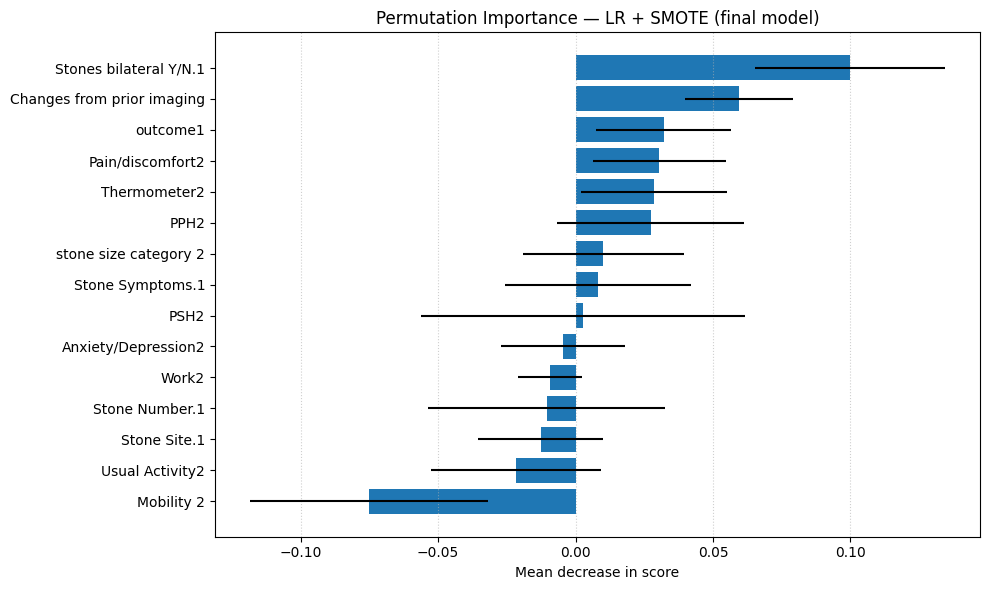

In [ ]:
# ============================================================================
# SECTION 11: PERMUTATION IMPORTANCE (Feature Importance Analysis)
# ============================================================================
# Analyze which features most impact model predictions
# ---- After your CV + final fit block ----
# You already have: pipe_smote_lr.fit(X2_train, y2_train)

from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, f1_score, roc_auc_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 0) Choose the scorer consistent with your evaluation
if is_binary:
    # Use the primary metric you report (e.g., 'roc_auc' or 'f1')
    # For PI, use f1 to avoid AUC undefined cases on some permutations
    scorer = "f1"  # or make_scorer(f1_score, average="binary", zero_division=0)
else:
    scorer = make_scorer(f1_score, average="macro", zero_division=0)  # multi-class safe

# 1) Ensure X2_test is numeric & aligned
X2_test_df = pd.DataFrame(X2_test).copy()
X2_test_df = X2_test_df.apply(pd.to_numeric, errors="coerce")
if X2_test_df.isna().any().any():
    # Safe fallback just for PI computation
    X2_test_df = X2_test_df.fillna(X2_test_df.median(numeric_only=True))

# 2) Feature names: prefer X2_test_df.columns; fall back to your list if provided
try:
    feat_names = list(X2_test_df.columns)
except Exception:
    feat_names = list(features2)

# 3) Run permutation importance on the FINAL fitted pipeline (SMOTE acts only during fit)
pi = permutation_importance(
    estimator=pipe_smote_lr,
    X=X2_test_df,
    y=y2_test,
    scoring=scorer,
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# 4) Build DF
df_perm = pd.DataFrame({
    "feature": feat_names,
    "mean_importance": pi.importances_mean,
    "std_importance":  pi.importances_std
})

# 5) Plot (no saving—only show in VS Code)
plot_importances(df_perm, title="Permutation Importance — LR + SMOTE (final model)", top_n=20)

# 6) (Optional) Inspect top features as a table
df_perm.sort_values("mean_importance", ascending=False).head(25)


In [ ]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from scipy.stats import loguniform

smote_sampling_space = ["auto", "not minority", "not majority", "all", "minority"]

param_dist = {
    "smote__k_neighbors": [3, 5, 7, 9],
    "smote__sampling_strategy": smote_sampling_space,  # minority:majority after resampling
    "clf__C": loguniform(1e-3, 1e2),
    "clf__class_weight": [None, "balanced"],        # try with/without
    # If you use elastic net:
    # "clf__penalty": ["elasticnet"],
    # "clf__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
    # "clf__solver": ["saga"],
}

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    pipe_smote_lr, param_distributions=param_dist, n_iter=40,
    scoring="balanced_accuracy", cv=inner_cv, n_jobs=-1, random_state=RANDOM_STATE
)
search.fit(X2_train, y2_train)
best_model = search.best_estimator_
print("Best params:", search.best_params_)


Best params: {'clf__C': np.float64(0.0745934328572655), 'clf__class_weight': None, 'smote__k_neighbors': 7, 'smote__sampling_strategy': 'not majority'}


d:\anaconda\envs\test\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
# Use the best params you found
best_params = {
    "clf__C": 0.0745934328572655,           # np.float64 -> plain float is fine
    "clf__class_weight": None,
    "smote__k_neighbors": 7,
    "smote__sampling_strategy": "not majority"
}

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, f1_score, balanced_accuracy_score
)
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
is_binary = (len(np.unique(y2_train)) == 2)

# Pipeline: scale -> SMOTE -> LR (scaling helps SMOTE's kNN geometry)
pipe = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf",   LogisticRegression(penalty="l2", solver="lbfgs",
                                 max_iter=500, random_state=RANDOM_STATE))
])
pipe.set_params(**best_params)

# --- 1) Tune decision threshold on OOF probabilities (train only) ---
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def pick_threshold(y_true, y_scores, metric="f1"):
    ths = np.linspace(0.05, 0.95, 19)
    if metric == "f1":
        scores = [f1_score(y_true, (y_scores >= t).astype(int)) for t in ths]
    else:
        scores = [balanced_accuracy_score(y_true, (y_scores >= t).astype(int)) for t in ths]
    return ths[int(np.argmax(scores))]

if is_binary:
    # Out-of-fold probabilities from TRAIN for fair threshold selection
    oof_proba = cross_val_predict(
        pipe, X2_train, y2_train, cv=inner_cv, method="predict_proba", n_jobs=-1
    )[:, 1]
    thr = pick_threshold(y2_train, oof_proba, metric="f1")
else:
    thr = None  # Thresholding is for binary only

print(f"Chosen threshold (train OOF): {thr:.3f}" if thr is not None else "Multiclass: using argmax")

# --- 2) Fit on full training set & evaluate on the untouched test ---
pipe.fit(X2_train, y2_train)

if is_binary:
    test_proba = pipe.predict_proba(X2_test)[:, 1]
    y2_pred = (test_proba >= thr).astype(int)
else:
    # Multiclass normal prediction
    y2_pred = pipe.predict(X2_test)

print("\n=== Hold-out Test Set ===")
print(classification_report(y2_test, y2_pred))
print("Confusion Matrix:\n", confusion_matrix(y2_test, y2_pred))

if is_binary:
    print(f"ROC AUC: {roc_auc_score(y2_test, test_proba):.3f}")
    print(f"PR AUC (Average Precision): {average_precision_score(y2_test, test_proba):.3f}")


Multiclass: using argmax

=== Hold-out Test Set ===
              precision    recall  f1-score   support

           0       0.33      0.43      0.38         7
           1       0.76      0.54      0.63        24
           2       0.55      1.00      0.71         6

    accuracy                           0.59        37
   macro avg       0.55      0.66      0.57        37
weighted avg       0.65      0.59      0.60        37

Confusion Matrix:
 [[ 3  4  0]
 [ 6 13  5]
 [ 0  0  6]]


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE


pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf",   LogisticRegression(penalty="l2", solver="lbfgs",
                                 C=0.1, class_weight=None,
                                 max_iter=500, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"acc":"accuracy", "bal_acc":"balanced_accuracy",
           "f1_macro":"f1_macro", "f1_weighted":"f1_weighted"}

cv_res = cross_validate(pipe, X2, y2, cv=cv, scoring=scoring, return_train_score=False)
for k,v in cv_res.items():
    if k.startswith("test_"):
        print(f"{k[5:]:<12}: {v.mean():.3f} ± {v.std():.3f}")

# Out-of-fold predictions for a single report & confusion matrix
y2_pred_oof = cross_val_predict(pipe, X2, y2, cv=cv)
print("\nClassification Report (OOF):")
print(classification_report(y2, y2_pred_oof))
print("Confusion Matrix (OOF):\n", confusion_matrix(y2, y2_pred_oof))


acc         : 0.570 ± 0.075
bal_acc     : 0.617 ± 0.083
f1_macro    : 0.567 ± 0.061
f1_weighted : 0.591 ± 0.065

Classification Report (OOF):
              precision    recall  f1-score   support

           0       0.30      0.57      0.39        21
           1       0.76      0.52      0.62        79
           2       0.59      0.76      0.67        21

    accuracy                           0.57       121
   macro avg       0.55      0.62      0.56       121
weighted avg       0.65      0.57      0.59       121

Confusion Matrix (OOF):
 [[12  9  0]
 [27 41 11]
 [ 1  4 16]]


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet

# Test different penalties with cross-validation
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0, 0.25, 0.5, 0.75, 1]  # 0=Ridge, 1=Lasso
}

model = GridSearchCV(ElasticNet(), param_grid, cv=5)
model.fit(X2_train, y2_train)

print("Best parameters:", model.best_params_)

d:\anaconda\envs\test\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.696e+00, tolerance: 2.594e-03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
d:\anaconda\envs\test\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.553e+00, tolerance: 2.099e-03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_mode

Best parameters: {'alpha': 0.1, 'l1_ratio': 0.25}


d:\anaconda\envs\test\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.599e+00, tolerance: 2.594e-03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
d:\anaconda\envs\test\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.857e+00, tolerance: 2.099e-03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_mode

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.svm import SVC

# Example: initialise
svm = SVC( C=10,
    class_weight=None,
    gamma='scale',
    kernel='rbf',
    random_state=42 )

# Train the SVM
svm.fit(X2_train, y2_train)

# Predict on test set
y2_pred = svm.predict(X2_test)

# Evaluate
print("Classification Report SVM\n", classification_report(y2_test, y2_pred))
print("Confusion Matrix:\n", confusion_matrix(y2_test, y2_pred))


Classification Report SVM
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.61      0.58      0.60        24
           2       0.67      0.67      0.67         6

    accuracy                           0.49        37
   macro avg       0.43      0.42      0.42        37
weighted avg       0.50      0.49      0.49        37

Confusion Matrix:
 [[ 0  7  0]
 [ 8 14  2]
 [ 0  2  4]]


In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42))
])

param_grid = {
    "svm__C": [0.1, 1, 3, 10, 30],
    "svm__gamma": ["scale", 0.1, 0.03, 0.01, 0.003]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1_macro",      # or "balanced_accuracy"
    cv=cv,
    n_jobs=-1
)
gs.fit(X2_train, y2_train)

print("Best params:", gs.best_params_)

# Evaluate on held-out test set
best = gs.best_estimator_
y2_pred = best.predict(X2_test)
print("\nClassification Report:\n", classification_report(y2_test, y2_pred))
print("Confusion Matrix:\n", confusion_matrix(y2_test, y2_pred))


Best params: {'svm__C': 10, 'svm__gamma': 0.003}

Classification Report:
               precision    recall  f1-score   support

           0       0.32      0.86      0.46         7
           1       0.86      0.25      0.39        24
           2       0.55      1.00      0.71         6

    accuracy                           0.49        37
   macro avg       0.57      0.70      0.52        37
weighted avg       0.70      0.49      0.45        37

Confusion Matrix:
 [[ 6  1  0]
 [13  6  5]
 [ 0  0  6]]


In [ ]:
# ============================================================================
# XGBOOST WITH SMOTE
# ============================================================================
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Create the XGBoost Classifier
xgb = XGBClassifier(
    objective='multi:softprob',           # Multiclass softmax
    num_class=3,                          # Use the correct number of classes in your dataset
    eval_metric='mlogloss',               # Suitable for multiclass
    # use_label_encoder=False,              # Avoid warning in newer versions
    random_state=42,
    enable_categorical=True
)

# Fit the model
xgb.fit(X2_train, y2_train)

# Predict
y2_pred = xgb.predict(X2_test)

# Evaluation
print("Classification Report XGB:\n", classification_report(y2_test, y2_pred))
print("Confusion Matrix:\n", confusion_matrix(y2_test, y2_pred))


Classification Report XGB:
               precision    recall  f1-score   support

           0       0.33      0.29      0.31         7
           1       0.71      0.62      0.67        24
           2       0.40      0.67      0.50         6

    accuracy                           0.57        37
   macro avg       0.48      0.53      0.49        37
weighted avg       0.59      0.57      0.57        37

Confusion Matrix:
 [[ 2  4  1]
 [ 4 15  5]
 [ 0  2  4]]


In [ ]:
# ============================================================================
# XGBOOST WITH SMOTE
# ============================================================================

# XGBoost + SMOTE + Stratified CV (Multi-class)
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, balanced_accuracy_score
)

RANDOM_STATE = 42
N_SPLITS = 5

# --- Ensure numeric (same helper as before) ---
def to_float32(X):
    if isinstance(X, pd.DataFrame):
        return X.apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float32)
    return np.asarray(X, dtype=np.float32)

Xtr = to_float32(X2_train)
Xte = to_float32(X2_test)

# --- Encode y as 0..K-1 ---
ytr = pd.Series(y2_train).to_numpy().ravel().astype(int)
yte = pd.Series(y2_test).to_numpy().ravel().astype(int)

classes = np.unique(ytr)
n_classes = len(classes)
print(f"Detected {n_classes} classes: {classes}")

xgb_params = dict(
    objective="multi:softprob",    
    num_class=n_classes,
    eval_metric="mlogloss",
    learning_rate=0.1,
    max_depth=5,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# --- Pipeline: SMOTE -> XGB ---

pipe_xgb_smote = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ("xgb", XGBClassifier(**xgb_params))
])

# --- Stratified CV scoring ---
scoring = {
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
    "bal_acc": "balanced_accuracy"
}

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cv_res = cross_validate(
    pipe_xgb_smote, Xtr, ytr,
    scoring=scoring, cv=cv,
    n_jobs=-1, return_train_score=False
)


print("XGBoost + SMOTE — Cross-Validation (Train only)\n\n")

for k, v in cv_res.items():
    if k.startswith("test_"):
        metric = k.replace("test_", "")
        print(f"{metric:>15s}: mean={np.mean(v):.3f} | std={np.std(v):.3f}\n")
print( "\n")

# --- Fit on full training set ---
pipe_xgb_smote.fit(Xtr, ytr)

# --- Hold-out evaluation ---
y_pred = pipe_xgb_smote.predict(Xte)


print("XGBoost + SMOTE — Hold-out Evaluation (Test set)\n\n")

print("Classification Report:\n", classification_report(yte, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(yte, y_pred))
print("\nBalanced Accuracy:", balanced_accuracy_score(yte, y_pred))
print("\nMacro F1:", f1_score(yte, y_pred, average="macro"))
print("\nWeighted F1:", f1_score(yte, y_pred, average="weighted"))



Detected 3 classes: [0 1 2]
XGBoost + SMOTE — Cross-Validation (Train only)


       f1_macro: mean=0.612 | std=0.161

    f1_weighted: mean=0.702 | std=0.124

        bal_acc: mean=0.611 | std=0.136



XGBoost + SMOTE — Hold-out Evaluation (Test set)


Classification Report:
               precision    recall  f1-score   support

           0       0.20      0.14      0.17         7
           1       0.73      0.67      0.70        24
           2       0.50      0.83      0.62         6

    accuracy                           0.59        37
   macro avg       0.48      0.55      0.50        37
weighted avg       0.59      0.59      0.58        37


Confusion Matrix:
 [[ 1  5  1]
 [ 4 16  4]
 [ 0  1  5]]

Balanced Accuracy: 0.5476190476190476

Macro F1: 0.4957729468599033

Weighted F1: 0.5841167254210733


                       feature  mean_importance  std_importance
12  Changes from prior imaging         0.033057        0.028644
14                    outcome1         0.024268        0.026094
9          Anxiety/Depression2         0.019168        0.024928
7             Pain/discomfort2         0.017476        0.035836
10      Stones bilateral Y/N.1         0.010606        0.018851
3        stone size category 2         0.006392        0.020261
0             Stone Symptoms.1         0.004257        0.049217
13             Usual Activity2         0.000000        0.000000
4               Stone Number.1        -0.003909        0.038076
6                 Thermometer2        -0.005824        0.052931
5                        Work2        -0.028587        0.035025
1                         PPH2        -0.040160        0.050484
2                         PSH2        -0.044512        0.043904
11                Stone Site.1        -0.045902        0.016950
8                   Mobility 2        -0

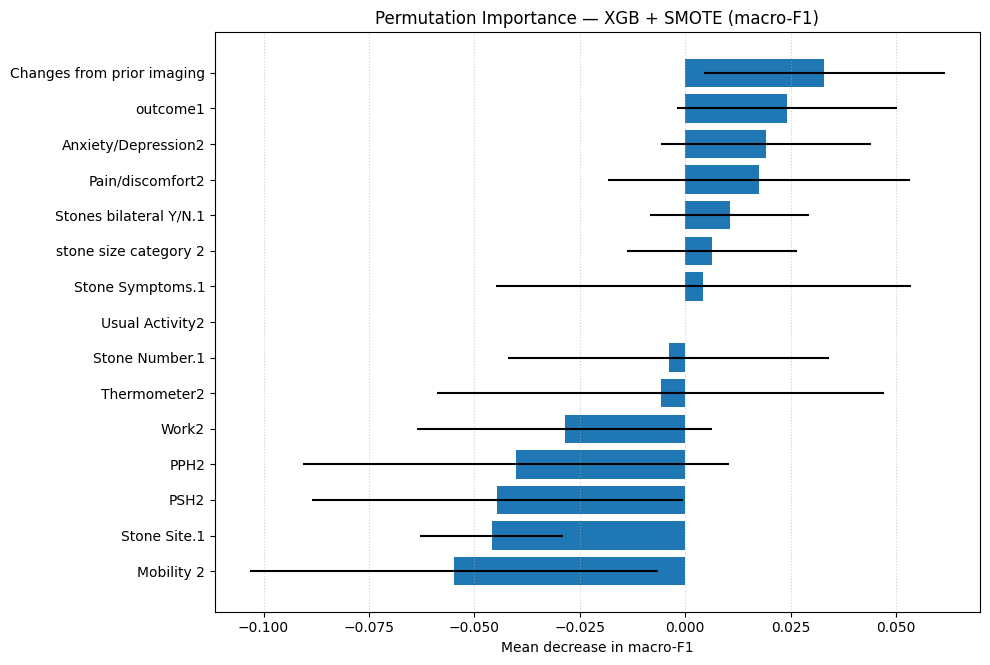

In [ ]:
# ============================================================================
# SECTION 11: PERMUTATION IMPORTANCE (Feature Importance Analysis)
# ============================================================================
# Analyze which features most impact model predictions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# --- 1) Pick evaluation data & feature names (keep names if you have them) ---
if isinstance(X2_test, pd.DataFrame):
    X_pi = X2_test.apply(pd.to_numeric, errors="coerce")
    feat_names = X_pi.columns.tolist()
else:
    X_pi = Xte  # your numeric hold-out array from above
    feat_names = [f"f{i}" for i in range(X_pi.shape[1])]

# --- 2) Permutation importance (macro-F1 for multiclass) ---
pi = permutation_importance(
    pipe_xgb_smote,   # fitted pipeline (SMOTE is inert at predict-time)
    X_pi,
    yte,
    scoring="f1_macro",
    n_repeats=50,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# --- 3) Assemble results ---
df_perm = pd.DataFrame({
    "feature": feat_names,
    "mean_importance": pi.importances_mean,
    "std_importance":  pi.importances_std,
}).sort_values("mean_importance", ascending=False)

print(df_perm.head(25))

# --- 4) Plot helper (horizontal bar chart) ---
def plot_importances(df, title="", top_n=20, ax=None):
    required = {"feature", "mean_importance"}
    if not required.issubset(df.columns):
        raise ValueError("df must contain 'feature' and 'mean_importance'")
    d = df.sort_values("mean_importance", ascending=False).head(top_n).iloc[::-1]
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(d))))
    else:
        fig = ax.figure
    xerr = d["std_importance"] if "std_importance" in d.columns else None
    ax.barh(d["feature"], d["mean_importance"], xerr=xerr)
    ax.set_title(title)
    ax.set_xlabel("Mean decrease in macro-F1")
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle=":", alpha=0.6)
    plt.tight_layout()
    return fig, ax

# --- 5) Plot top-20 features ---
fig, ax = plot_importances(df_perm, title="Permutation Importance — XGB + SMOTE (macro-F1)", top_n=20)
plt.show()


In [ ]:
# import numpy as np
# import pandas as pd
# from imblearn.ensemble import BalancedRandomForestClassifier
# from sklearn.impute import SimpleImputer
# from sklearn.metrics import (
#     classification_report,
#     confusion_matrix,
#     balanced_accuracy_score,
#     f1_score,
#     roc_auc_score,
#     average_precision_score
# )

# # --- 1) One-hot encode categoricals & align ---
# Xtr = pd.get_dummies(X2_train, drop_first=True)
# Xte = pd.get_dummies(X2_test, drop_first=True)
# Xtr, Xte = Xtr.align(Xte, join="left", axis=1, fill_value=0)

# # --- 2) Impute missing values ---
# imp = SimpleImputer(strategy="median")
# Xtr_imp = imp.fit_transform(Xtr)
# Xte_imp = imp.transform(Xte)

# # --- 3) y to 1D arrays ---
# ytr = pd.Series(y2_train).to_numpy().ravel()
# yte = pd.Series(y2_test).to_numpy().ravel()

# # --- 4) Balanced Random Forest ---
# brf = BalancedRandomForestClassifier(
#     n_estimators=400,
#     max_depth=None,
#     min_samples_split=5,
#     min_samples_leaf=2,
#     max_features="sqrt",
#     sampling_strategy="not_majority",   # under-sample majority vs minority
#     replacement=False,                  # no replacement for under-sampled data
#     random_state=42,
#     n_jobs=-1
# )

# brf.fit(Xtr_imp, ytr)

# # --- 5) Predictions & probabilities ---
# yp = brf.predict(Xte_imp)
# proba = brf.predict_proba(Xte_imp)

# # --- 6) Evaluation ---
# print("Balanced Random Forest — Test Results")
# print("Balanced Accuracy:", balanced_accuracy_score(yte, yp))
# print("Macro F1:", f1_score(yte, yp, average="macro"))
# print("\nClassification Report:\n", classification_report(yte, yp))
# print("Confusion Matrix:\n", confusion_matrix(yte, yp))

# try:
#     roc_auc = roc_auc_score(yte, proba, multi_class="ovr", average="macro")
#     pr_auc = average_precision_score(yte, proba, average="macro")
#     print("ROC AUC (OvR, macro):", roc_auc)
#     print("PR AUC  (macro):", pr_auc)
# except Exception as e:
#     print("ROC/PR AUC could not be computed:", e)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# --- 1) One-hot encode categoricals & align columns ---
Xtr = pd.get_dummies(X2_train, drop_first=True)
Xte = pd.get_dummies(X2_test, drop_first=True)
Xtr, Xte = Xtr.align(Xte, join="left", axis=1, fill_value=0)

# --- 2) Impute missing values ---
imp = SimpleImputer(strategy="mean")
Xtr_imp = imp.fit_transform(Xtr)
Xte_imp = imp.transform(Xte)

# --- 3) y to 1D arrays ---
ytr = pd.Series(y2_train).to_numpy().ravel()
yte = pd.Series(y2_test).to_numpy().ravel()

# --- 4) Train Random Forest with balanced class weights ---
# rf_bal = RandomForestClassifier(
#     n_estimators=400,
#     max_depth=None,
#     class_weight=None,
#     random_state=42,
#     n_jobs=-1
# )
rf_bal = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_bal.fit(Xtr_imp, ytr)

# --- 5) Predictions & probabilities ---
yp = rf_bal.predict(Xte_imp)
proba = rf_bal.predict_proba(Xte_imp)   # shape: (n_samples, n_classes)

# --- 6) Evaluation ---
print("Random Forest")
print(classification_report(yte, yp))
print("Confusion Matrix:\n", confusion_matrix(yte, yp))

# ROC AUC and PR AUC for multi-class
try:
    roc_auc = roc_auc_score(yte, proba, multi_class="ovr", average="macro")
    pr_auc = average_precision_score(yte, proba, average="macro")
    print("ROC AUC (OvR, macro):", roc_auc)
    print("PR AUC  (macro):", pr_auc)
except Exception as e:
    print("ROC/PR AUC could not be computed:", e)


Random Forest
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.69      0.75      0.72        24
           2       0.62      0.83      0.71         6

    accuracy                           0.62        37
   macro avg       0.44      0.53      0.48        37
weighted avg       0.55      0.62      0.58        37

Confusion Matrix:
 [[ 0  7  0]
 [ 3 18  3]
 [ 0  1  5]]
ROC AUC (OvR, macro): 0.7101264327070779
PR AUC  (macro): 0.6028762909252223


In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

# Decide explicit target counts (e.g., upsample minorities to 80% of the majority)
cnt = Counter(ytr)
maj = max(cnt.values())
target_counts = {c: max(cnt[c], int(0.8 * maj)) for c in cnt}  # up to 80% of majority
print("SMOTE target counts:", target_counts)

pipe = ImbPipeline(steps=[
    ("imp",   SimpleImputer(strategy="median")),
    ("smote", SMOTE(random_state=42, sampling_strategy=target_counts, k_neighbors=3)),
    ("rf",    RandomForestClassifier(
                n_estimators=400,
                max_depth=None,
                min_samples_split=5,
                min_samples_leaf=2,
                max_features="sqrt",
                bootstrap=True,
                class_weight=None,     # SMOTE handles balance
                criterion="log_loss",
                random_state=42,
                n_jobs=-1
             ))
])

pipe.fit(Xtr, ytr)
yp    = pipe.predict(Xte)
proba = pipe.predict_proba(Xte)

print("RF after SMOTE")
print(classification_report(yte, yp))
print("Confusion Matrix:\n", confusion_matrix(yte, yp))
print("ROC AUC (OvR, macro):", roc_auc_score(yte, proba, multi_class="ovr", average="macro"))
print("PR AUC  (macro):",     average_precision_score(yte, proba, average="macro"))


SMOTE target counts: {np.int64(2): 44, np.int64(1): 55, np.int64(0): 44}
RF after SMOTE
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.69      0.75      0.72        24
           2       0.62      0.83      0.71         6

    accuracy                           0.62        37
   macro avg       0.44      0.53      0.48        37
weighted avg       0.55      0.62      0.58        37

Confusion Matrix:
 [[ 0  7  0]
 [ 3 18  3]
 [ 0  1  5]]
ROC AUC (OvR, macro): 0.6846380322186775
PR AUC  (macro): 0.582328017549568


                       feature  mean_importance  std_importance
6                 Thermometer2         0.045635        0.021359
12  Changes from prior imaging         0.040967        0.015747
3        stone size category 2         0.040301        0.021282
14                    outcome1         0.010120        0.011161
10      Stones bilateral Y/N.1         0.009075        0.018953
13             Usual Activity2         0.008357        0.011644
11                Stone Site.1         0.000000        0.000000
2                         PSH2        -0.003686        0.029839
9          Anxiety/Depression2        -0.010548        0.014962
7             Pain/discomfort2        -0.014777        0.030995
8                   Mobility 2        -0.026236        0.038664
0             Stone Symptoms.1        -0.035944        0.041207
5                        Work2        -0.047837        0.050059
1                         PPH2        -0.050319        0.046238
4               Stone Number.1        -0

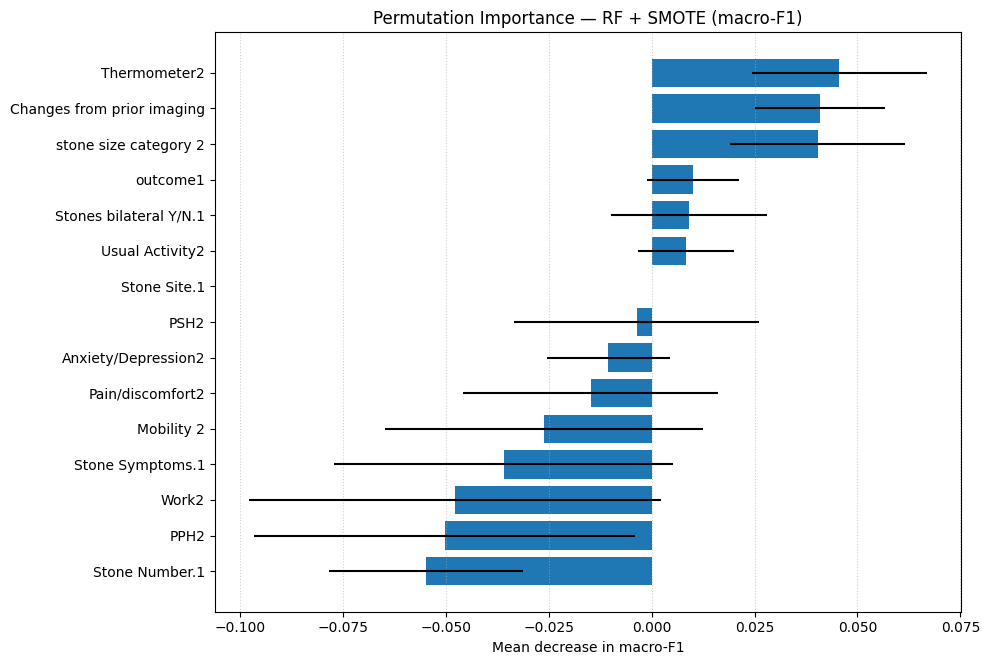

In [ ]:
# ============================================================================
# SECTION 11: PERMUTATION IMPORTANCE (Feature Importance Analysis)
# ============================================================================
# Analyze which features most impact model predictions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# 1) Choose evaluation set + names
if isinstance(X2_test, pd.DataFrame):
    X_pi = X2_test.apply(pd.to_numeric, errors="coerce")
    feat_names = X_pi.columns.tolist()
else:
    X_pi = Xte  # your numeric test array
    feat_names = [f"f{i}" for i in range(X_pi.shape[1])]

# 2) Permutation importance (macro-F1 is robust to imbalance)
pi = permutation_importance(
    pipe,            # fitted ImbPipeline(SMOTE -> RF); SMOTE is inert at predict-time
    X_pi, yte,
    scoring="f1_macro",
    n_repeats=50,
    random_state=42,
    n_jobs=-1
)

# 3) Collect results
df_perm = pd.DataFrame({
    "feature": feat_names,
    "mean_importance": pi.importances_mean,
    "std_importance":  pi.importances_std
}).sort_values("mean_importance", ascending=False)

print(df_perm.head(25))

# 4) Plot helper (use yours if already defined)
def plot_importances(df, title="", top_n=20, ax=None):
    d = df.sort_values("mean_importance", ascending=False).head(top_n).iloc[::-1]
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(d))))
    else:
        fig = ax.figure
    xerr = d.get("std_importance", None)
    ax.barh(d["feature"], d["mean_importance"], xerr=xerr)
    ax.set_title(title)
    ax.set_xlabel("Mean decrease in macro-F1")
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle=":", alpha=0.6)
    plt.tight_layout()
    return fig, ax

# 5) Plot top features
plot_importances(df_perm, title="Permutation Importance — RF + SMOTE (macro-F1)", top_n=20)
plt.show()


In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score, roc_auc_score, average_precision_score
import pandas as pd

# --- 1) One-hot encode & align ---
Xtr = pd.get_dummies(X2_train, drop_first=True)
Xte = pd.get_dummies(X2_test,  drop_first=True)
Xtr, Xte = Xtr.align(Xte, join="left", axis=1, fill_value=0)

# --- 2) Impute ---
imp = SimpleImputer(strategy="median")
Xtr_imp = imp.fit_transform(Xtr)
Xte_imp = imp.transform(Xte)

# --- 3) y ---
ytr = pd.Series(y2_train).to_numpy().ravel()
yte = pd.Series(y2_test).to_numpy().ravel()

# --- 4) Balanced Random Forest (fixed sampling_strategy) ---
brf = BalancedRandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    sampling_strategy="not majority",  # <-- space, not underscore
    replacement=False,
    random_state=42,
    n_jobs=-1
)

brf.fit(Xtr_imp, ytr)

# --- 5) Evaluate ---
yp    = brf.predict(Xte_imp)
proba = brf.predict_proba(Xte_imp)

print("Balanced Random Forest — Test Results")
print("Balanced Accuracy:", balanced_accuracy_score(yte, yp))
print("Macro F1:", f1_score(yte, yp, average="macro"))
print("\nClassification Report:\n", classification_report(yte, yp))
print("Confusion Matrix:\n", confusion_matrix(yte, yp))

try:
    print("ROC AUC (OvR, macro):", roc_auc_score(yte, proba, multi_class="ovr", average="macro"))
    print("PR AUC  (macro):",     average_precision_score(yte, proba, average="macro"))
except Exception as e:
    print("ROC/PR AUC could not be computed:", e)


Balanced Random Forest — Test Results
Balanced Accuracy: 0.5476190476190476
Macro F1: 0.5356125356125356

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.14      0.22         7
           1       0.71      0.83      0.77        24
           2       0.57      0.67      0.62         6

    accuracy                           0.68        37
   macro avg       0.60      0.55      0.54        37
weighted avg       0.65      0.68      0.64        37

Confusion Matrix:
 [[ 1  6  0]
 [ 1 20  3]
 [ 0  2  4]]
ROC AUC (OvR, macro): 0.7096685572492024
PR AUC  (macro): 0.6276944197924693


d:\anaconda\envs\test\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but BalancedRandomForestClassifier was fitted without feature names
  warnings.warn(


,feature,mean_importance,std_importance
0,Stone Symptoms.1,0.127935,0.091250
2,PSH2,0.078894,0.030818
6,Thermometer2,0.010265,0.037258
4,Stone Number.1,0.007984,0.024758
10,Stones bilateral Y/N.1,0.000000,0.000000
9,Anxiety/Depression2,0.000000,0.000000
7,Pain/discomfort2,0.000000,0.000000
13,Usual Activity2,0.000000,0.000000
11,Stone Site.1,0.000000,0.000000
3,stone size category 2,-0.002074,0.035197


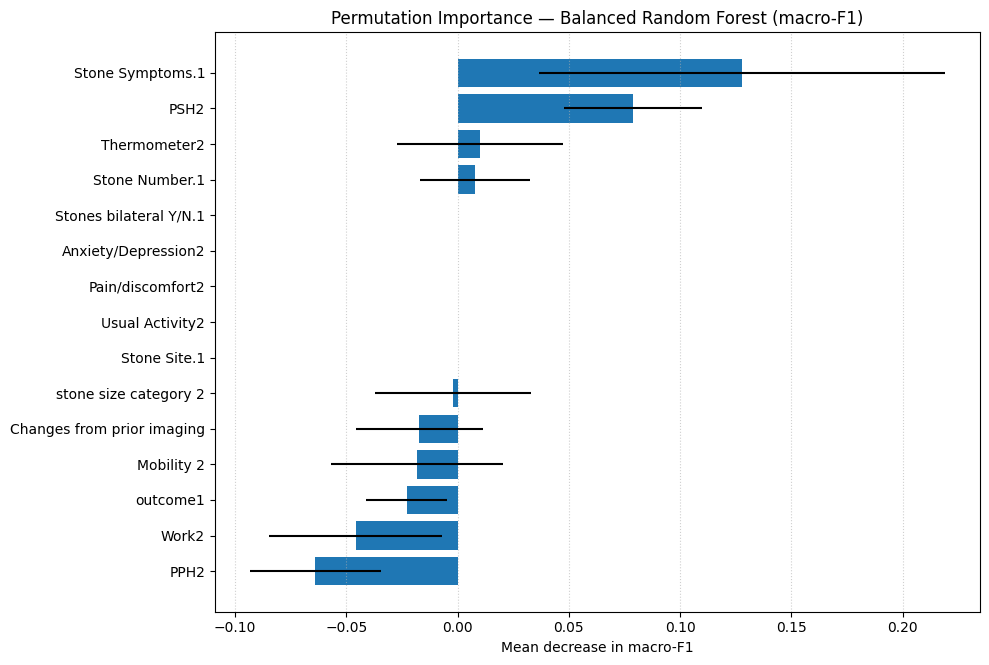

In [ ]:
# ============================================================================
# SECTION 11: PERMUTATION IMPORTANCE (Feature Importance Analysis)
# ============================================================================
# Analyze which features most impact model predictions
# --- Permutation Importance for Balanced Random Forest (multi-class) ---
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Recreate a DataFrame for X_test *after* imputation so we retain feature names in the plot
feat_names = list(Xte.columns)                 # one-hot names from your alignment step
Xte_imp_df = pd.DataFrame(Xte_imp, columns=feat_names)

# 2) Robust scorer for multi-class
pi_scorer = make_scorer(f1_score, average="macro", zero_division=0)

# 3) Run permutation importance on the FINAL fitted model
pi = permutation_importance(
    estimator=brf,              # already fitted above
    X=Xte_imp_df,
    y=yte,
    scoring=pi_scorer,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

# 4) Pack results
df_perm_brf = pd.DataFrame({
    "feature": feat_names,
    "mean_importance": pi.importances_mean,
    "std_importance":  pi.importances_std
})

# 5) Show plot inline (no saving)
plot_importances(
    df_perm_brf,
    title="Permutation Importance — Balanced Random Forest (macro-F1)",
    top_n=20
)

# 6) (Optional) Inspect top features as a table
df_perm_brf.sort_values("mean_importance", ascending=False).head(25)


In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(xgb, max_num_features=15)
plt.show()


In [ ]:
# ============================================================================
# SECTION 11: PERMUTATION IMPORTANCE (Feature Importance Analysis)
# ============================================================================
# Analyze which features most impact model predictions
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, f1_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Defensive copy of X2_test
X_df = pd.DataFrame(X2_test).copy()
X_df = X_df.apply(pd.to_numeric, errors="coerce").fillna(0)

# Safe scorer (avoids errors if a class is missing)
scorer = make_scorer(f1_score, average="macro", zero_division=0)

# Run permutation importance
r = permutation_importance(
    lr, X_df, y2_test,
    scoring=scorer,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

# DataFrame of results
imp_df = pd.DataFrame({
    "feature": X_df.columns,
    "importance_mean": r.importances_mean,
    "importance_std": r.importances_std
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

# Plot (no saving, just show)
top_n = 15
top = imp_df.head(top_n)

plt.figure(figsize=(10, max(4, 0.35 * len(top))))
plt.barh(top["feature"][::-1], top["importance_mean"][::-1])
plt.xlabel("Permutation importance (macro-F1)")
plt.title("Top features — Logistic Regression (Visit 2)")
plt.tight_layout()
plt.show()

imp_df.head(20)  # also see the top 20 as a table


In [ ]:
# ============================================================================
# SECTION 11: PERMUTATION IMPORTANCE (Feature Importance Analysis)
# ============================================================================
# Analyze which features most impact model predictions
# --- Import(s)
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# helper: tidy bar plot
def plot_importances(df_imp, title, top_n=20):
    df_imp = df_imp.sort_values('mean_importance', ascending=True).tail(top_n)
    ax = df_imp.plot(kind='barh', x='feature', y='mean_importance', xerr='std_importance', legend=False, figsize=(7, 6))
    ax.set_xlabel("Permutation importance (Δscore)")
    ax.set_ylabel("")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# EXAMPLE USAGE:
# Assume you already have: model_rf (fitted), X_test, y_test, feature_names = X_test.columns
# IMPORTANT: run permutation on the FINAL fitted model; never refit inside this step.
result = permutation_importance(
    estimator=lr,
    X=X2_test,
    y=y2_test,
    scoring="f1_macro",     # choose metric you care about (accuracy, f1_macro, balanced_accuracy, etc.)
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

df_perm = pd.DataFrame({
    "feature": features2,
    "mean_importance": result.importances_mean,
    "std_importance": result.importances_std
})

plot_importances(df_perm, title="Permutation Importance LR Baseline", top_n=20)
df_perm.sort_values("mean_importance", ascending=False).head(25)


In [ ]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X2_train, y2_train)
xgb.fit(X_res, y_res)

In [ ]:
df_visit3_xa['Mobility 3'].fillna(df_visit3_xa['Mobility 3'].mode()[0], inplace=True)
df_visit3_xa['Selfcare3'].fillna(df_visit3_xa['Selfcare3'].mode()[0], inplace=True)
df_visit3_xa['Usual Activity3'].fillna(df_visit3_xa['Usual Activity3'].mode()[0], inplace=True)
df_visit3_xa['Pain/discomfort3'].fillna(df_visit3_xa['Pain/discomfort3'].mode()[0], inplace=True)
df_visit3_xa['Anxiety/Depression3'].fillna(df_visit3_xa['Anxiety/Depression3'].mode()[0], inplace=True)
df_visit3_xa['Stone Number.2'].fillna(df_visit3_xa['Stone Number.2'].mode()[0], inplace=True)
df_visit3_xa['Thermometer3'].fillna(df_visit3_xa['Thermometer3'].mean(), inplace=True)
# df_visit3_xa.drop(columns='Comments.1',inplace=True)
"""
Missing values in df_visit1:
Mobility 1              4
Selfcare1               3
Usual Activity1         3
Pain/discomfort1        4
Anxiety/Depression1     3
Thermometer1            6
Comments               58"""


In [ ]:
# Reuse the numeric DataFrame from before
numeric_df = df_visit3_xa.select_dtypes(include=['number'])

# Compute the correlation matrix
corr_matrix = numeric_df.corr().abs()

# Find columns with any correlation > 0.35 (excluding self-correlation)
relevant_cols = corr_matrix.columns[(corr_matrix > 0.29).any() ]

# Filter the correlation matrix to include only those columns
filtered_corr = numeric_df[relevant_cols].corr()

# Mask the upper triangle
mask = np.triu(np.ones_like(filtered_corr, dtype=bool))

# Plot the reduced correlation matrix
plt.figure(figsize=(15, 15))
sns.heatmap(filtered_corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Visit 3- Filtered Correlation Matrix (|r| > 0.29")
plt.show()


In [ ]:
numeric_df = df_visit3_xa.select_dtypes(include=['number'])
correlations = numeric_df.corr()['outcome3_recode'].drop('outcome3_recode').abs()
high_corr_cols = correlations[correlations > 0.29].index.tolist()
print(high_corr_cols)


In [ ]:
# ============================================================================
# PROCESSING VISIT-2 DATA
# ============================================================================
df_visit3_xa['outcome1']=df_visit1_xa['outcome1_recode']
df_visit3_xa['outcome2']=df_visit2_xa['outcome2_recode']

In [ ]:
numeric_df = df_visit3_xa.select_dtypes(include=['number'])
correlations = numeric_df.corr()['outcome3_recode'].drop('outcome3_recode').abs()
high_corr_cols = correlations[correlations > 0.29].index.tolist()
print(high_corr_cols)


In [ ]:
df_visit3_xa['Significant change in score .1'].fillna(df_visit3_xa['Significant change in score .1'].mode(), inplace=True)

In [ ]:
features3=['Stone Symptoms.2', 'PPH3', 'PSH3', 'Significant change in score .1', 'Mobility 3', 'Anxiety/Depression3',
          'Thermometer3', 'outcome2','outcome1', 'Changes from prior imaging.1','Work3']
target = 'outcome3_recode'  


X3 = df_visit3_xa[features3]
y3 = df_visit3_xa[target]


In [ ]:
X3['Significant change in score .1'] = X3['Significant change in score .1'].fillna(X3['Significant change in score .1'].mode()[0])

In [ ]:
X3.isna().sum()  


In [ ]:
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.30, stratify=y3, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# # Fit logistic regression
# # lr = LogisticRegression(multi_class='ovr', class_weight='balanced', random_state=42, max_iter=1000)
lr = LogisticRegression(
    C=4,
    class_weight= "balanced",
    max_iter=500,
    penalty='l2',
    solver='lbfgs',
    random_state=42
)

# lr=LogisticRegression(penalty='elasticnet', l1_ratio=0.5, C=0.1, class_weight='balanced', solver='saga', max_iter=1000)
# lr=LogisticRegression(penalty='l1', C=1.0, class_weight='balanced', solver='saga', max_iter=500)

lr.fit(X3_train, y3_train)
# Predict on test set
y3_pred = lr.predict(X3_test)

# Evaluation
print("Classification Report (Logistic Regression):\n", classification_report(y3_test, y3_pred))
print("Confusion Matrix:\n", confusion_matrix(y3_test, y3_pred))

# Optional: ROC-AUC (binary only or OvR)
if len(np.unique(y3_test)) == 2:
    y3_proba = lr.predict_proba(X3_test)[:, 1]
    auc = roc_auc_score(y3_test, y3_proba)
    print(f"ROC AUC Score: {auc:.3f}")


In [ ]:
# ============================================================================
# SECTION 11: PERMUTATION IMPORTANCE (Feature Importance Analysis)
# ============================================================================
# Analyze which features most impact model predictions
# --- Import(s)
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# helper: tidy bar plot
def plot_importances(df_imp, title, top_n=20):
    df_imp = df_imp.sort_values('mean_importance', ascending=True).tail(top_n)
    ax = df_imp.plot(kind='barh', x='feature', y='mean_importance', xerr='std_importance', legend=False, figsize=(7, 6))
    ax.set_xlabel("Permutation importance (Δscore)")
    ax.set_ylabel("")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# EXAMPLE USAGE:
# Assume you already have: model_rf (fitted), X_test, y_test, feature_names = X_test.columns
# IMPORTANT: run permutation on the FINAL fitted model; never refit inside this step.
result = permutation_importance(
    estimator=lr,
    X=X3_test,
    y=y3_test,
    scoring="f1_macro",     # choose metric you care about (accuracy, f1_macro, balanced_accuracy, etc.)
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

df_perm = pd.DataFrame({
    "feature": features3,
    "mean_importance": result.importances_mean,
    "std_importance": result.importances_std
})

plot_importances(df_perm, title="Permutation Importance ", top_n=20)
df_perm.sort_values("mean_importance", ascending=False).head(25)


In [ ]:
df_visit4_xa.columns

In [ ]:
bins = [0, 40, 60, 80, 100]
labels = [0, 1, 2, 3]

# Apply binning
df_visit4_xa['Thermometer_bin4'] = pd.cut(
    df_visit4_xa['Thermometer4'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True)

In [ ]:
# Reuse the numeric DataFrame from before
numeric_df = df_visit4_xa.select_dtypes(include=['number'])

# Compute the correlation matrix
corr_matrix = numeric_df.corr().abs()

# Find columns with any correlation > 0.35 (excluding self-correlation)
relevant_cols = corr_matrix.columns[(corr_matrix > 0.29).any() ]

# Filter the correlation matrix to include only those columns
filtered_corr = numeric_df[relevant_cols].corr()

# Mask the upper triangle
mask = np.triu(np.ones_like(filtered_corr, dtype=bool))

# Plot the reduced correlation matrix
plt.figure(figsize=(15, 15))
sns.heatmap(filtered_corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Visit 4- Filtered Correlation Matrix (|r| > 0.29)")
plt.show()


## Summary: Key Findings

### Visit-1 Results (Initial Triage - Binary Classification)
**Best Model:** Logistic Regression + SMOTE
- Accuracy: 0.92
- Intervention Recall: 0.88
- F1-score: 0.82
- ROC-AUC: 0.944

**Key Predictors:**
1. Stone Symptoms (dominant)
2. Stone Size Category
3. PPH (Pain & Physical Health)
4. Pain/Discomfort
5. Usual Activity Impact

**Interpretation:** Early triage driven by symptom burden and physical impact.

---

### Visit-2 Results (Follow-up - Multi-class Classification)
**Best Model:** Balanced Random Forest
- Accuracy: 0.68
- Macro F1: 0.54
- Intervention Recall: 0.83
- Discharge Recall: 0.14 (limited by data scarcity)

**Key Predictors:**
1. Stone Symptoms (dominant)
2. PSH (Psycho-Social Health) ← increasingly important
3. Global Health Thermometer
4. Changes from Prior Imaging
5. Stone Size/Site

**Interpretation:** Psycho-social factors gain importance at follow-up; model struggles with rare 'discharge' outcome due to severe class imbalance.

---

## Clinical Implications

1. **PROM-Driven Triage:** Patient-reported outcomes (USIQoL domains) provide additional predictive value beyond clinical variables alone.

2. **Longitudinal Evolution:** Feature importance shifts across patient journey:
   - Early: Symptom severity dominates
   - Follow-up: Psycho-social impact emerges as critical

3. **Practical Utility:** Models support evidence-based triaging in NHS PIFU (Patient-Initiated Follow-Up) and remote monitoring pathways.

---

## Limitations

- Small single-centre dataset (121 visits) limits generalisability
- Severe class imbalance (especially Visit-2)
- SMOTE provides partial solutions; larger prospective data recommended
- External validation needed before clinical deployment

---

## Future Directions

1. Multicentre prospective data collection (target: n > 500 visits)
2. Advanced imbalance-handling: cost-sensitive learning, class weights
3. Transfer learning from related domains
4. Real-world validation in NHS clinical pathways
5. Continuous model monitoring post-deployment